# When Fair Enough Is Not Enough

## Allocation Policies and Long-Term Benefit Gaps

This portfolio notebook implements the empirical component of a broader review of long-term fairness. It uses 2018 California ACS microdata to compare how allocation rules and targeting strategies distribute employment support in one-shot and repeated-decision settings.

The simulation is inspired by three complementary ideas: evaluate the policy that turns scores into decisions, model the environment changed by repeated intervention, and aggregate benefit relative to need over time. It is not an exact replication of any single paper.


## Summary

- The sample contains 46,942 working-age adults. The baseline logistic model reaches 0.735 accuracy and 0.705 ROC AUC.
- High-risk targeting produces higher job-finding rates among people needing support and lower timeout rates than middle-risk targeting.
- These are stylized simulation results, not causal estimates of real employment-program effects.


## Context & Methods

The experiment treats predicted unemployment risk as an input to a support-allocation policy. Static policies are evaluated in a single round, then three policy families are simulated repeatedly as support changes future employment probabilities and the active population is replenished.

### Key assumptions

- Employment status is used as a proxy for support need.
- Sex is the sensitive attribute and is excluded from model features.
- Simulated support effects, probability decay, and timeout exits are modeling assumptions rather than estimated causal effects.
- Equal opportunity uses observed need and is therefore an idealized static benchmark.

### Environment

Install the repository dependencies with `python -m pip install -r requirements.txt` before running the notebook. The first run requires internet access so `folktables` can download ACS files; later runs can use the local cache.


### Imports

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data

### ACS source and task definition

Folktables (https://github.com/socialfoundations/folktables) is a Python package that provides access to datasets derived from the US Census, facilitating the benchmarking of machine learning algorithms. he package includes a suite of pre-defined prediction tasks in domains including income, employment, health, transportation, and housing, and also includes tools for creating new prediction tasks of interest in the US Census data ecosystem. The package additionally enables systematic studies of the effect of distribution shift, as each prediction task can be instantiated on datasets spanning multiple years and all states within the US.


In [12]:
from folktables import ACSDataSource, BasicProblem

YEAR = "2018"
STATE = ["CA"]

In [145]:
# Define sex as the sensitive group instead of the Folktables default (RAC1P).

ACSEmployment = BasicProblem(
    features=[
        "AGEP", "SCHL", "MAR", "RELP", "DIS", "ESP", "CIT", "MIG",
        "MIL", "ANC", "NATIVITY", "DEAR", "DEYE", "DREM",
        "SEX", "RAC1P"
    ],
    target="ESR",
    target_transform=lambda x: x == 1,
    group="SEX",
    preprocess=lambda x: x,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

#Target = ESR: Employment status recode (class = 1: civilian employed at work)

In [146]:
data_source = ACSDataSource(
    survey_year=YEAR,
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=STATE, download=True)

features, label, group = ACSEmployment.df_to_numpy(acs_data)

In [147]:
# Convert arrays to a labeled DataFrame.

feature_names = ACSEmployment.features

df = pd.DataFrame(features, columns=feature_names)
df["employed"] = label.astype(int)

df.head(5)

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,SEX,RAC1P,employed
0,30.0,14.0,1.0,16.0,2.0,0.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,2.0,1.0,8.0,0
1,18.0,14.0,5.0,17.0,2.0,0.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,0
2,69.0,17.0,1.0,17.0,1.0,0.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,9.0,0
3,25.0,1.0,5.0,17.0,1.0,0.0,1.0,1.0,4.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,0
4,31.0,18.0,5.0,16.0,2.0,0.0,1.0,1.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,0


**ACSEmployment feature dictionary**

| Variable | Meaning | Notes |
|---|---|---|
| `AGEP` | Age | Person's age. |
| `SCHL` | Educational attainment | Highest level of schooling completed. |
| `MAR` | Marital status | Married, widowed, divorced, separated, never married. |
| `RELP` | Relationship | Relationship to the household reference person. |
| `DIS` | Disability recode | Whether the person has a disability. |
| `ESP` | Employment status of parents | Relevant mostly for younger people living with parents. |
| `CIT` | Citizenship status | U.S.-born, naturalized citizen, not a citizen, etc. |
| `MIG` | Mobility status one year ago | Whether and where the person moved from in the last year. |
| `MIL` | Military service | Current or past military service status. |
| `ANC` | Ancestry recode | Whether ancestry is single, multiple, unclassified, or not reported. |
| `NATIVITY` | Nativity | Native or foreign-born. |
| `DEAR` | Hearing difficulty | Whether the person is deaf or has serious difficulty hearing. |
| `DEYE` | Vision difficulty | Whether the person is blind or has serious difficulty seeing. |
| `DREM` | Cognitive difficulty | Serious difficulty remembering, concentrating, or making decisions. |
| `SEX` | Sex | ACS binary coding: male/female. Used as sensitive attribute in our main experiment. |
| `RAC1P` | Race recode | One-digit ACS race category. Default group variable in ACSEmployment. |
| `employed` | Employment outcome | Binary target created from `ESR`; 1 means employed under the Folktables task definition. |

### Exploration and preprocessing

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378817 entries, 0 to 378816
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   AGEP      378817 non-null  float64
 1   SCHL      378817 non-null  float64
 2   MAR       378817 non-null  float64
 3   RELP      378817 non-null  float64
 4   DIS       378817 non-null  float64
 5   ESP       378817 non-null  float64
 6   CIT       378817 non-null  float64
 7   MIG       378817 non-null  float64
 8   MIL       378817 non-null  float64
 9   ANC       378817 non-null  float64
 10  NATIVITY  378817 non-null  float64
 11  DEAR      378817 non-null  float64
 12  DEYE      378817 non-null  float64
 13  DREM      378817 non-null  float64
 14  SEX       378817 non-null  float64
 15  RAC1P     378817 non-null  float64
 16  employed  378817 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 49.1 MB


In [149]:
df["employed"].value_counts(1)

,proportion
employed,
0,0.543835
1,0.456165


**Filter**

Population from 16 to 90 (original application of Folktables with race)
Population from 18 to 64 (ACS Workforce)

In [150]:
df = df[(df["AGEP"] >= 18) & (df["AGEP"] <= 64)].reset_index(drop=True)

**Feature engineering**

For all categorical features non-binary, collapse categories to avoid non-representative features in the model (feature dictionary in https://www2.census.gov/programs-surveys/acs/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2018.txt)

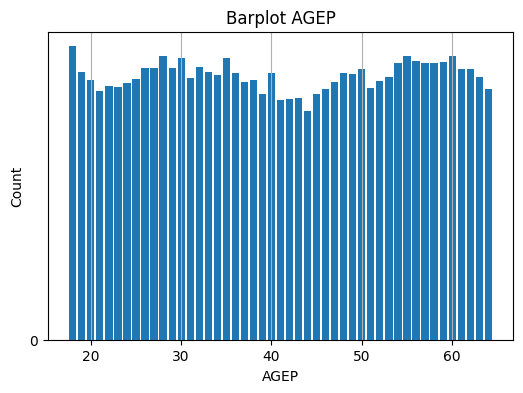

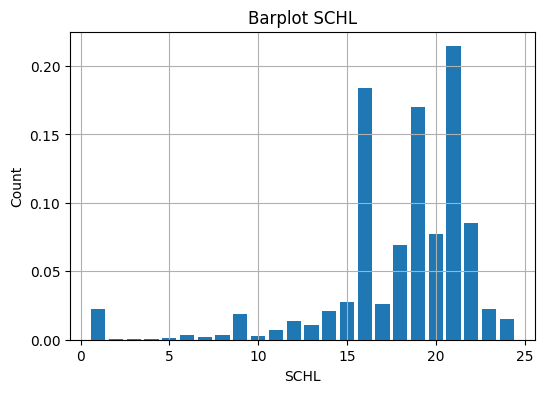

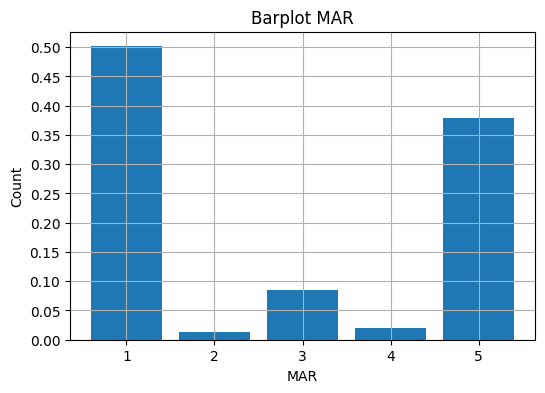

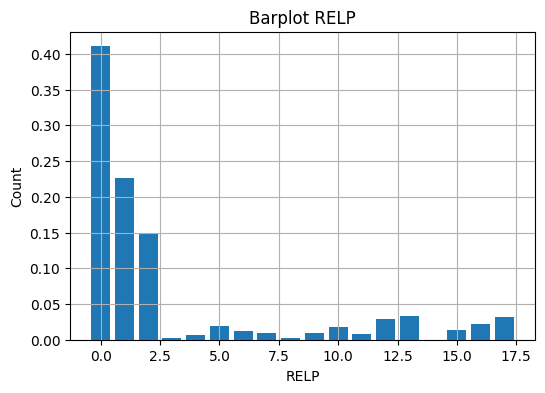

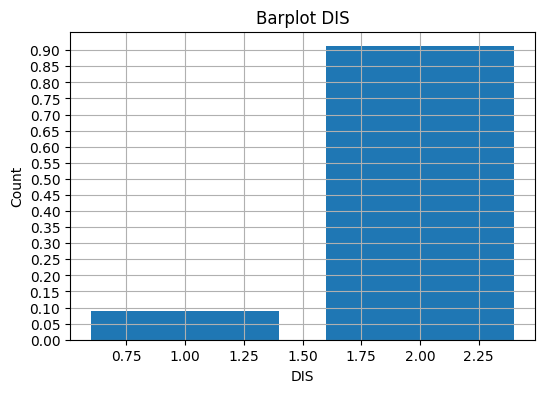

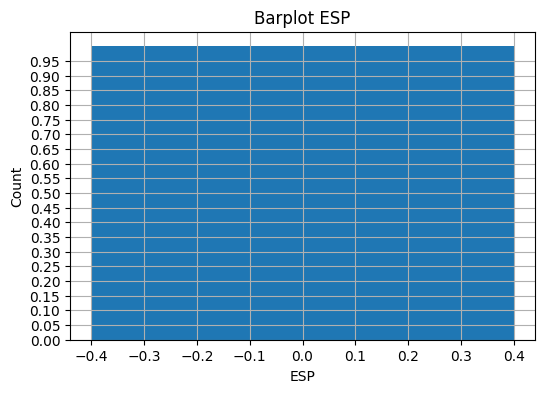

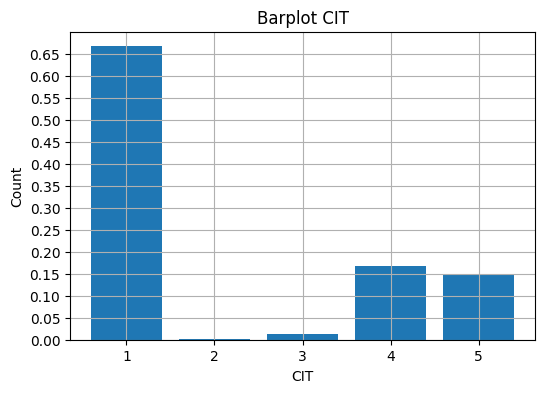

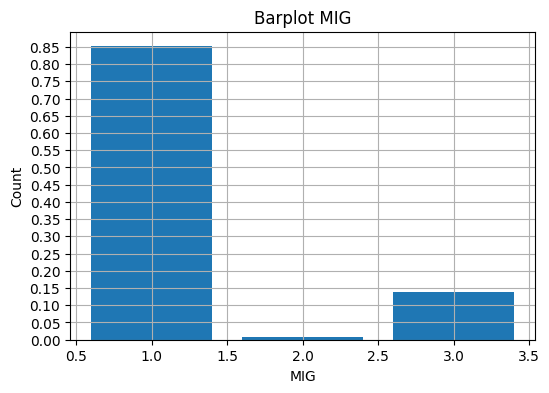

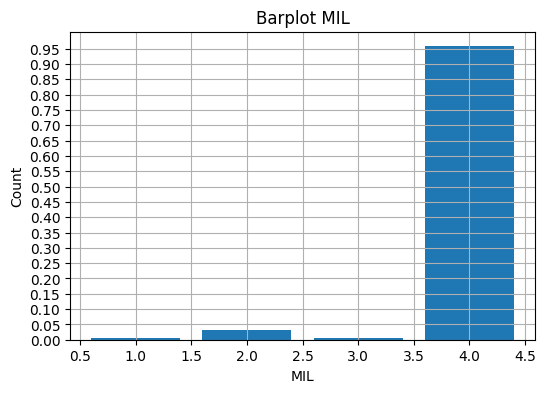

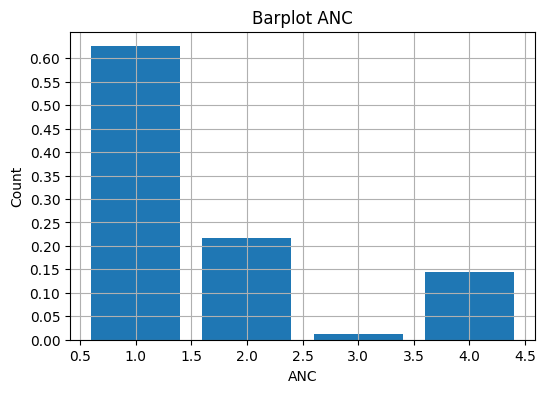

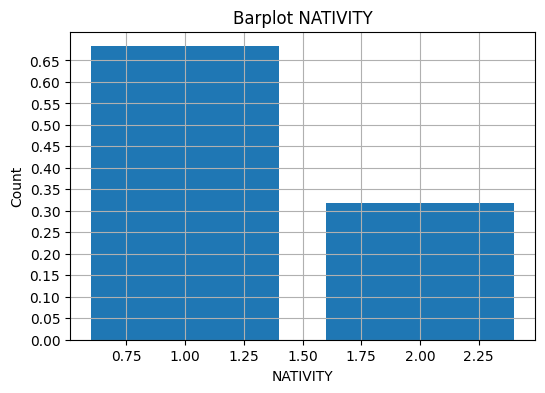

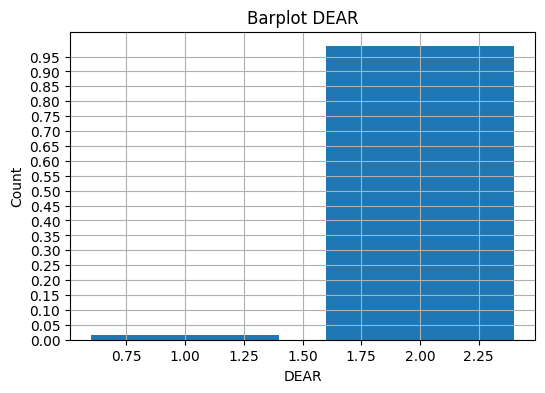

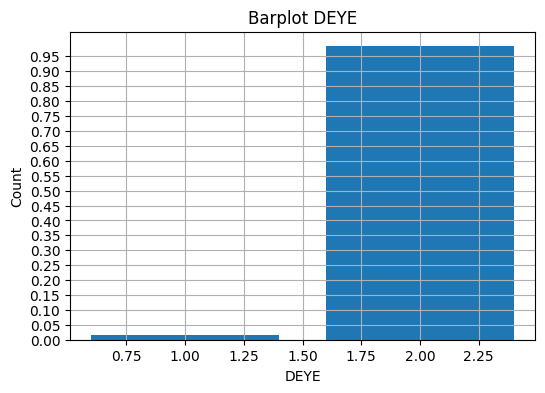

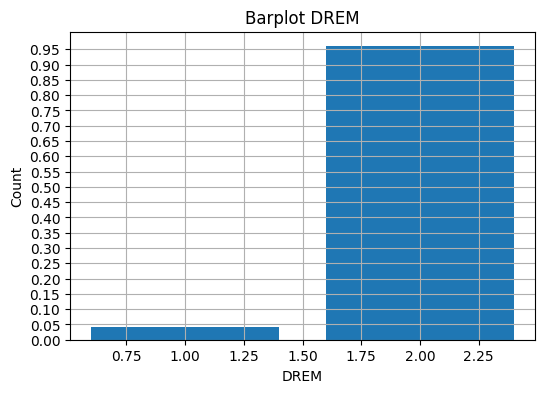

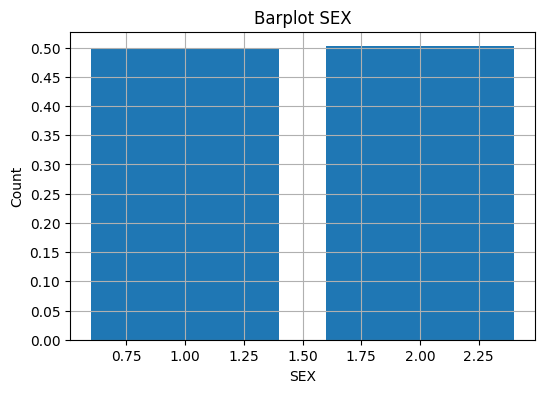

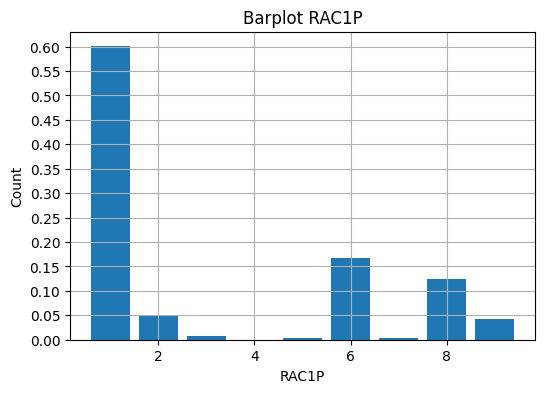

In [151]:
for i in df.columns:
  if i != 'employed':
    #create a barplot with matplotlib
    plt.figure(figsize=(6,4))
    plt.bar(df[i].value_counts(1).index, df[i].value_counts(1))
    plt.title(f'Barplot {i}' )
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.yticks(np.arange(0, np.max(df[i].value_counts(1)), 0.05))
    plt.grid(True)
    plt.show()


Collapse categories:
**SCHL**


*   1: Less than high school = 1-15
*   2: High school / GED = 16, 17
*   3: Some college = 18, 19
*   4: Associate degree = 20
*   5: Bachelor's degree = 21
*  6: Graduate degree = 22-24








In [152]:
# SCHL
df["SCHL"] = df["SCHL"].replace({
    **dict.fromkeys(range(1, 16), 1),   # Less than high school
    16: 2, 17: 2,                       # High school / GED
    18: 3, 19: 3,                       # Some college
    20: 4,                              # Associate degree
    21: 5,                              # Bachelor's degree
    22: 6, 23: 6, 24: 6                 # Graduate degree
})


Collapse categories:
**MAR**


*   1: Married = 1
*   2: Previously married (widowed, divorced, separated) = 2-4
*   3: Never married = 5









In [153]:
# MAR
df["MAR"] = df["MAR"].replace({
    1: 1,                               # Married
    2: 2, 3: 2, 4: 2,                  # Previously married
    5: 3                                # Never married
})

Collapse categories:
**RELP**


*   1: Reference person = 0
*   2: Spouse/Partner = 1, 13
*   3: Child (excluded for this analysis) = 2-4, 14
*   4: Other relative = 5-10
*   5: Non-relative / group quarters = 11,12,15-17









In [154]:
# RELP
df["RELP"] = df["RELP"].replace({
    0: 1,                               # Reference person
    1: 2, 13: 2,                        # Spouse/Partner
    2: 3, 3: 3, 4: 3, 14: 3,           # Child
    5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 4, # Other relative
    11: 5, 12: 5, 15: 5, 16: 5, 17: 5  # Non-relative / group quarters
})

Collapse categories:
**ESP**


*   1: Non-living w/parents = 0
*   2: Parents working = 1-3, 5, 7
*   3: Parents not working = 4, 6, 8










In [155]:

# ESP
df["ESP"] = df["ESP"].replace({
    0: 1,                               # Non-living w/parents
    1: 2, 2: 2, 3: 2, 5: 2, 7: 2,      # Parents working
    4: 3, 6: 3, 8: 3                   # Parents not working
})

Collapse categories:
**CIT**

*   1: US born = 1
*   2: US citizen by other route = 2-4
*   3: Not US citizen = 5

In [156]:
# CIT
df["CIT"] = df["CIT"].replace({
    1: 1,                               # US born
    2: 2, 3: 2, 4: 2,                  # US citizen by other route
    5: 3                                # Not US citizen
})

Collapse categories:
**MIL**

*   0: N/A (less than 17) = 0
*   1: Currently or Previously served = 1-3
*   2: Never served = 4


In [157]:
# MIL
df["MIL"] = df["MIL"].replace({
    0: 0,                               # N/A less than 17
    1: 1, 2: 1, 3: 1,                  # Currently or previously served
    4: 2                                # Never served
})

Collapse categories: **ANC**

*   1: "Single ancestry" = 1
*   2: "Multiple ancestry" = 2
*   3: "Unclassified" or "Not reported" = 3-4



In [158]:
# ANC
df["ANC"] = df["ANC"].replace({
    1: 1,                               # Single ancestry
    2: 2,                               # Multiple ancestry
    3: 3, 4: 3                          # Unclassified / Not reported
})

Collapse categories **RAC1P**

*  1: "White alone" = 1
*  2: "Black or African American alone" = 2
*  3: "Asian alone" = 6
*  4: "Other / multiracial" = 3-5, 7-9

In [159]:
# RAC1P
df["RAC1P"] = df["RAC1P"].replace({
    1: 1,                               # White alone
    2: 2,                               # Black or African American alone
    6: 3,                               # Asian alone
    3: 4, 4: 4, 5: 4, 7: 4, 8: 4, 9: 4 # Other / multiracial
})

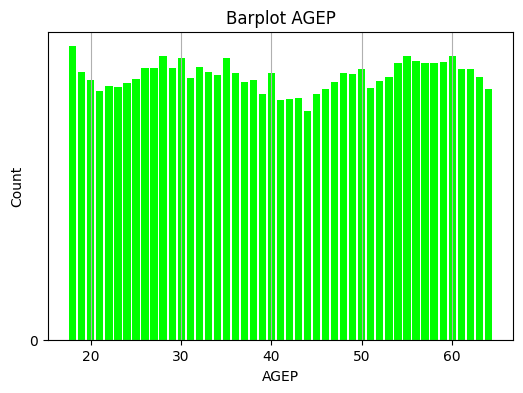

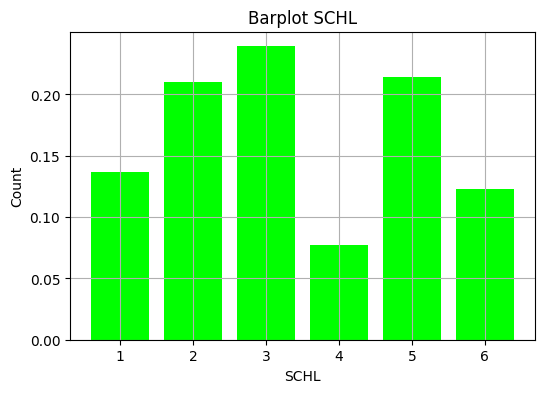

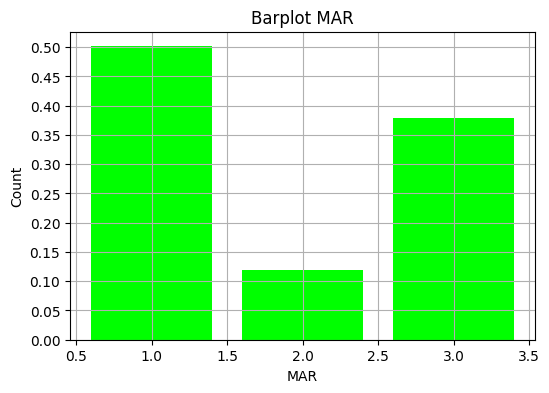

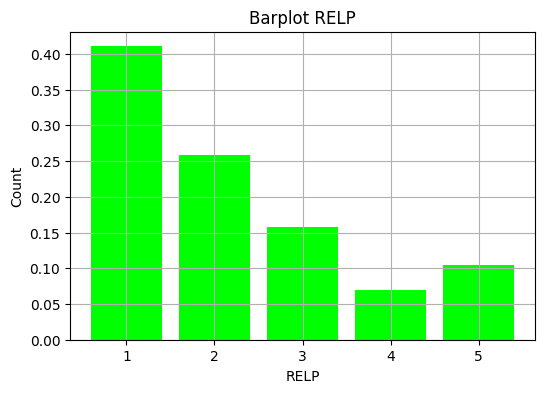

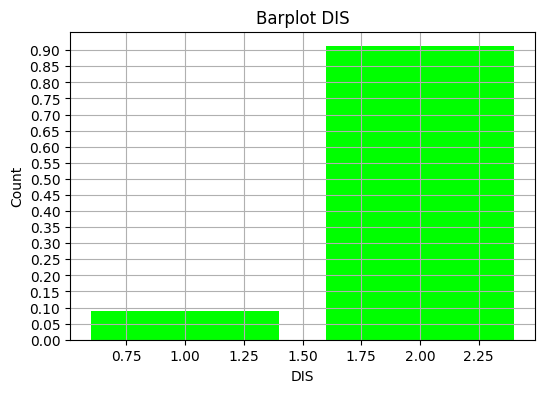

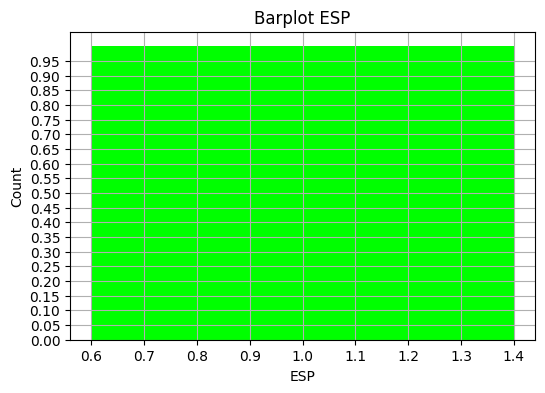

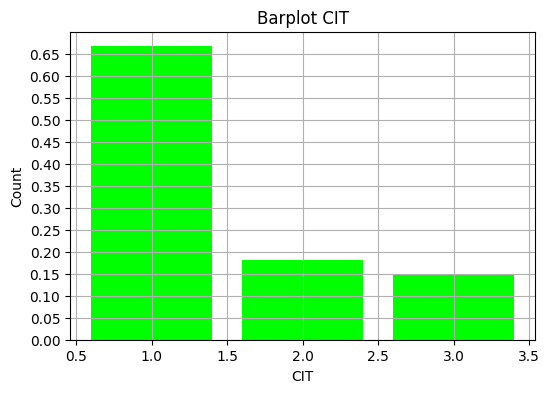

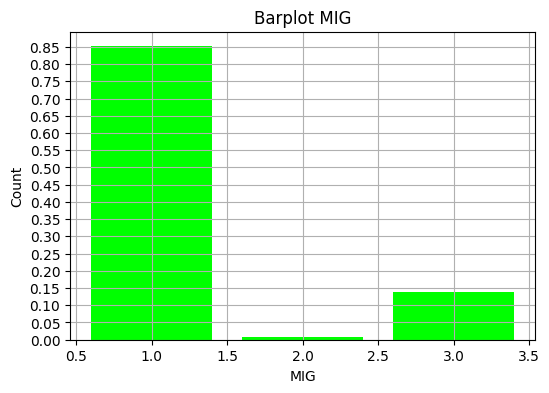

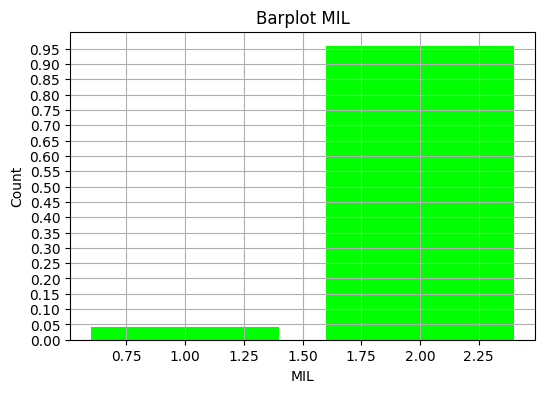

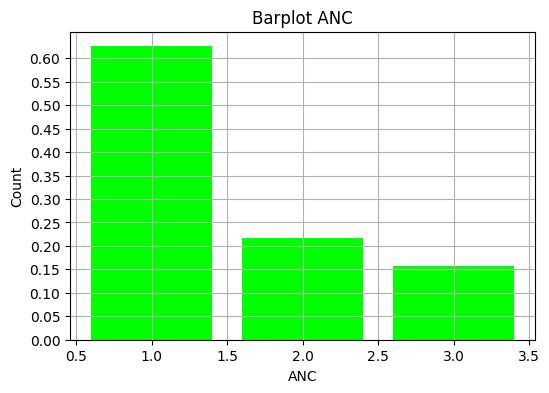

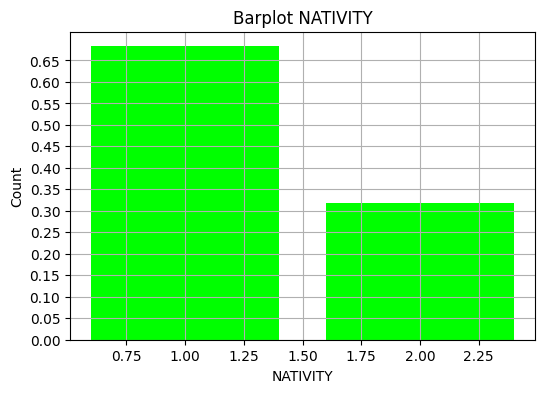

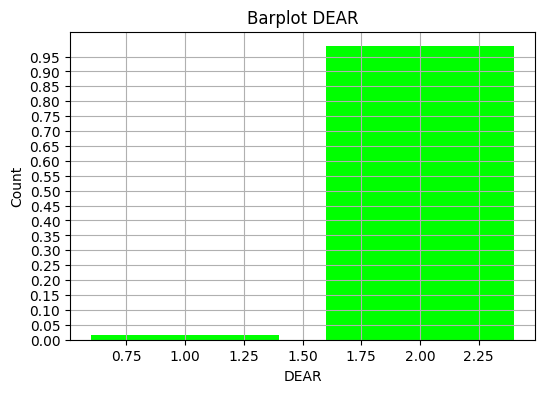

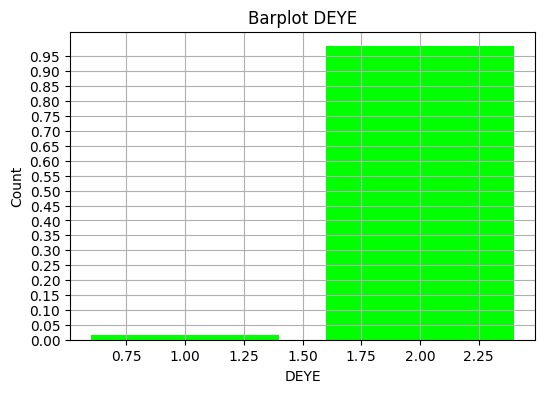

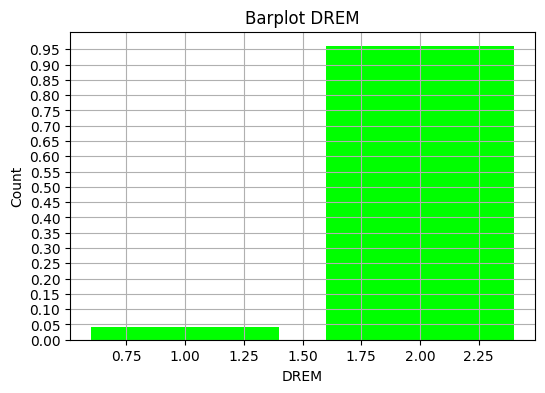

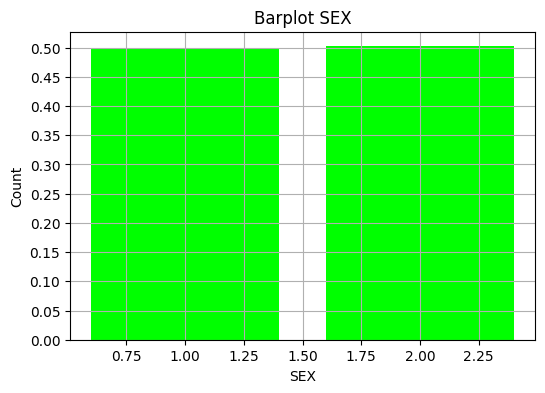

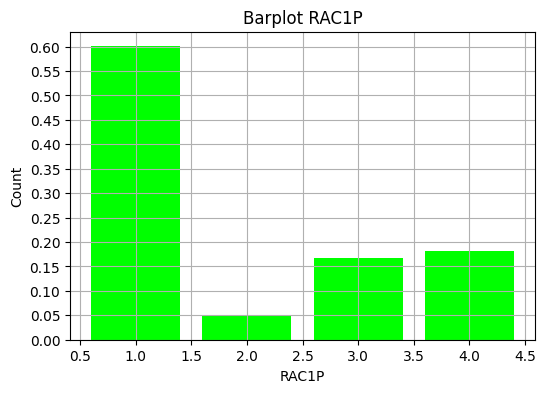

In [160]:
for i in df.columns:
  if i != 'employed':
    #barplot to check changes
    plt.figure(figsize=(6,4))
    plt.bar(df[i].value_counts(1).index, df[i].value_counts(1), color='lime')
    plt.title(f'Barplot {i}' )
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.yticks(np.arange(0, np.max(df[i].value_counts(1)), 0.05))
    plt.grid(True)
    plt.show()

### Train/test split

In [161]:
# Sensitive attribute
sensitive = df['SEX']

In [162]:
features_no_sensitive = [
    "AGEP", "SCHL", "MAR", "RELP", "DIS", "ESP", "CIT", "MIG",
    "MIL", "ANC", "NATIVITY", "DEAR", "DEYE", "DREM", "RAC1P"
]


In [163]:
numeric_features = ["AGEP"]
categorical_no_sensitive = [
    "SCHL", "MAR", "RELP", "DIS", "ESP", "CIT", "MIG", "MIL",
    "ANC", "NATIVITY", "DEAR", "DEYE", "DREM", "RAC1P"
]


In [164]:
X = df[features_no_sensitive]
y = df["employed"]

In [165]:
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model pipeline

In [166]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_no_sensitive)
    ]
)

model_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

#### Training

In [167]:
model_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AGEP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SCHL', 'MAR', 'RELP', 'DIS',
                                                   'ESP', 'CIT', 'MIG', 'MIL',
                                                   'ANC', 'NATIVITY', 'DEAR',
                                                   'DEYE', 'DREM',
                                                   'RAC1P'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

#### Validation

In [170]:
cat_labels = {
    1: "Male",
    2: "Female"
}


def metrics_by_group(y_true, y_pred, y_proba, group):
    rows = []

    for g in sorted(pd.Series(group).dropna().unique()):
        mask = group == g

        tn, fp, fn, tp = confusion_matrix(
            y_true[mask],
            y_pred[mask],
            labels=[0, 1]
        ).ravel()

        rows.append({
            "GROUP": g,
            "GROUP_label": cat_labels.get(g, g),
            "n": mask.sum(),
            "accuracy": accuracy_score(y_true[mask], y_pred[mask]),
            "auc": roc_auc_score(y_true[mask], y_proba[mask]) if y_true[mask].nunique() == 2 else np.nan,
            "selection_rate_pred_employed": y_pred[mask].mean(),
            "true_employment_rate": y_true[mask].mean(),
            "TPR_recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        })

    return pd.DataFrame(rows)

In [171]:
y_train_pred = model_base.predict(X_train)
y_train_proba = model_base.predict_proba(X_train)[:, 1]

train_group_metrics = metrics_by_group(
    y_train,
    y_train_pred,
    y_train_proba,
    sensitive_train
)

train_group_metrics

,GROUP,GROUP_label,n,accuracy,auc,selection_rate_pred_employed,true_employment_rate,TPR_recall,FPR,FNR
0,1.0,Male,93331,0.789277,0.759290,0.846857,0.724636,0.938933,0.604553,0.061067
1,2.0,Female,94434,0.680634,0.674354,0.888832,0.640310,0.944681,0.789413,0.055319


In [173]:
y_pred = model_base.predict(X_test)
y_proba = model_base.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.734757786204252
AUC: 0.7053016480418817

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.29      0.41     14917
           1       0.74      0.94      0.83     32025

    accuracy                           0.73     46942
   macro avg       0.72      0.62      0.62     46942
weighted avg       0.73      0.73      0.70     46942


Confusion matrix:
[[ 4340 10577]
 [ 1874 30151]]


In [172]:
validation_group_metrics = metrics_by_group(
    y_test,
    y_pred,
    y_proba,
    sensitive_test
)

validation_group_metrics

,GROUP,GROUP_label,n,accuracy,auc,selection_rate_pred_employed,true_employment_rate,TPR_recall,FPR,FNR
0,1.0,Male,23570,0.785320,0.758995,0.885278,0.725923,0.961894,0.682353,0.038106
1,2.0,Female,23372,0.676921,0.672599,0.832449,0.638157,0.899095,0.714911,0.100905


In [174]:
# Feature coefficients
feature_names_out = model_base.named_steps["preprocessor"].get_feature_names_out()
coefs = model_base.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names_out,
    "coefficient": coefs,
    "odds-ratio": np.exp(coefs)
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient,odds-ratio
16,cat__DIS_2.0,0.725690,2.066156
10,cat__RELP_1.0,0.633225,1.883675
6,cat__SCHL_6.0,0.574696,1.776591
21,cat__MIG_1.0,0.508023,1.662003
5,cat__SCHL_5.0,0.375245,1.455347
31,cat__DEAR_1.0,0.308298,1.361106
36,cat__DREM_2.0,0.287924,1.333655
23,cat__MIG_3.0,0.264343,1.302575
11,cat__RELP_2.0,0.197863,1.218795
33,cat__DEYE_1.0,0.175681,1.192058


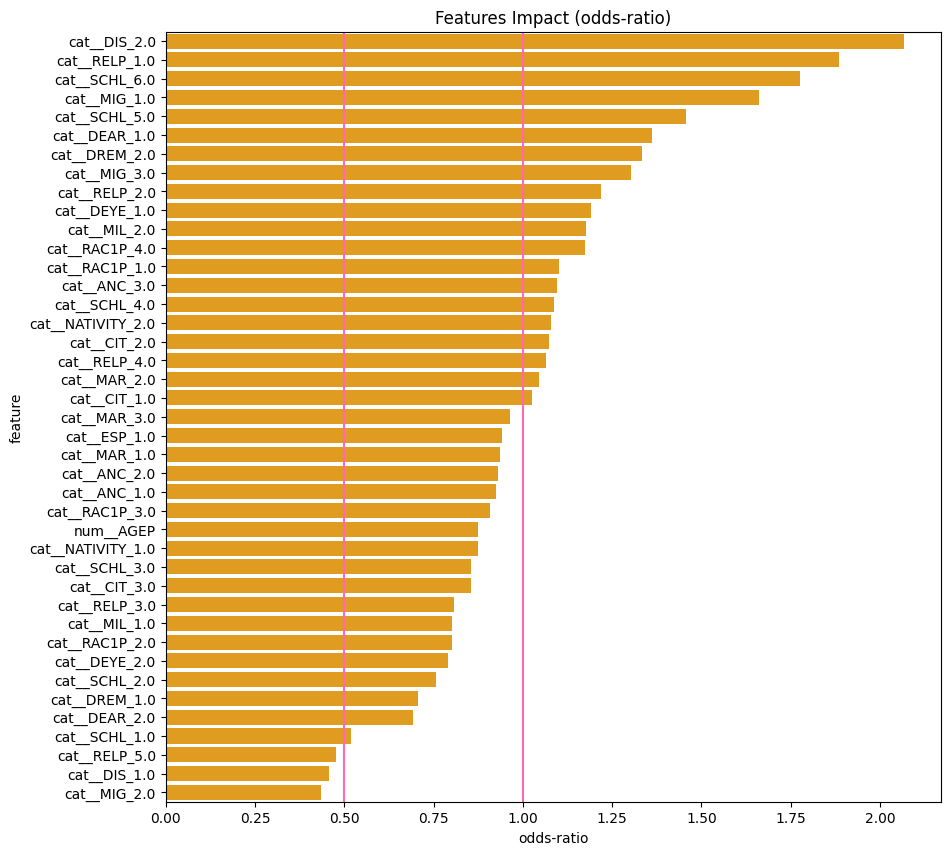

In [175]:
plt.figure(figsize=(10, 10))
sns.barplot(x='odds-ratio', y='feature', data=coef_df, color='orange')
plt.axvline(0.5, color="hotpink")
plt.axvline(1, color="hotpink")
plt.title("Features Impact (odds-ratio)")
plt.show()

## Results

### Static allocation

Create evaluation dataset.

In [176]:
y_proba = model_base.predict_proba(X_test)[:, 1]

eval_df = X_test.copy()
eval_df["y_true"] = y_test.values
eval_df["SEX"] = sensitive_test.values
eval_df["employment_prob"] = y_proba
eval_df["unemployment_risk"] = 1 - y_proba

eval_df.head()

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,RAC1P,y_true,SEX,employment_prob,unemployment_risk
187621,24.0,1.0,3.0,3.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,4.0,1,1.0,0.548267,0.451733
92030,63.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,1,1.0,0.743607,0.256393
208052,49.0,4.0,3.0,3.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,1,1.0,0.449326,0.550674
163411,58.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,3.0,1.0,2.0,2.0,2.0,1.0,1,2.0,0.673867,0.326133
15711,27.0,5.0,3.0,3.0,2.0,1.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,1,2.0,0.772761,0.227239


In [ ]:
eval_df["SEX_label"] = eval_df["SEX"].map({
    1: "Male",
    2: "Female"
})

We have that *y* is coded:

* 1: employed
* 0: not employed

Then, for simplicity let's define *"needs_support"* = 1 - y

* 0: does not need support
* 1: needs support

In [178]:
#A person needs help if:
eval_df["needs_support"] = 1 - eval_df["y_true"]

In [241]:
eval_df.groupby('SEX_label').agg(
    mean_unemployment_risk=('unemployment_risk', 'mean'),
    mean_employment_prob=('employment_prob', 'mean'),
    needs_support = ('needs_support', 'sum'), 
    total = ('SEX_label', 'count'))

,mean_unemployment_risk,mean_employment_prob,needs_support,total
SEX_label,,,,
Female,0.304991,0.695009,8457,23372
Male,0.330682,0.669318,6460,23570


#### Policy 1: Utility only

Select the p% with higher unemployment risk. Where p is the budget

In [ ]:
def allocate_utility_only(
    df,
    budget=0.30,
    targeting="high_risk",
    middle_low=0.3, #percentiles
    middle_high=0.7, 
    rng=None
):
    df = df.copy()
    n_select = int(len(df) * budget)

    if rng is None:
        rng = np.random.default_rng()

    if targeting == "high_risk":
        df["selected_utility_hr"] = 0

        selected_idx = (
            df
            .sort_values("unemployment_risk", ascending=False)
            .head(n_select)
            .index
        )

        df.loc[selected_idx, "selected_utility_hr"] = 1

    elif targeting == "middle_risk":
        df["selected_utility_mr"] = 0

        low_q = df["unemployment_risk"].quantile(middle_low)
        high_q = df["unemployment_risk"].quantile(middle_high)

        eligible = df[
            (df["unemployment_risk"] >= low_q) &
            (df["unemployment_risk"] <= high_q)
        ]

        n_select = min(n_select, len(eligible))

        selected_idx = (eligible.sort_values("unemployment_risk", ascending=False).head(n_select).index)

        df.loc[selected_idx, "selected_utility_mr"] = 1

    else:
        raise ValueError("targeting must be 'high_risk' or 'middle_risk'")

    return df

In [269]:
eval_df = allocate_utility_only(eval_df, budget=0.20, targeting="high_risk")

In [270]:
eval_df = allocate_utility_only(eval_df, budget=0.20, targeting="middle_risk")

#### Policy 2: Static demographic parity

Select the p% with higher unemployment risk within each group. Where p is the budget
Static demographic parity with middle-risk targeting selects the same budget share from each demographic group, restricting eligibility to the middle-risk range within each group

In [271]:
def allocate_demographic_parity(
    df,
    group_col="SEX",
    budget=0.30,
    targeting="high_risk",
    middle_low=0.3,
    middle_high=0.7,
    rng=None
):
    df = df.copy()
    if rng is None:
       rng = np.random.default_rng()

    if targeting == "high_risk":
        df["selected_dp_hr"] = 0

        for group_value, group_df in df.groupby(group_col):
            n_select = int(len(group_df) * budget)

            selected_idx = (
                group_df
                .sort_values("unemployment_risk", ascending=False)
                .head(n_select)
                .index
            )

            df.loc[selected_idx, "selected_dp_hr"] = 1

    elif targeting == "middle_risk":
        low_q = df["unemployment_risk"].quantile(middle_low)
        high_q = df["unemployment_risk"].quantile(middle_high)
        df["selected_dp_mr"] = 0

        for group_value, group_df in df.groupby(group_col):

            eligible = group_df[
                (group_df["unemployment_risk"] >= low_q) &
                (group_df["unemployment_risk"] <= high_q)
            ]

            n_select = int(len(group_df) * budget)
            n_select = min(n_select, len(eligible))

            selected_idx = (eligible.sort_values("unemployment_risk", ascending=False).head(n_select).index)

            df.loc[selected_idx, "selected_dp_mr"] = 1

    return df

In [272]:
eval_df = allocate_demographic_parity(eval_df, group_col="SEX", budget=0.20, targeting = "high_risk")

In [273]:
eval_df = allocate_demographic_parity(eval_df, group_col="SEX", budget=0.20, targeting = "middle_risk")

In [274]:
eval_df.head(3)

,AGEP,SCHL,MAR,RELP,DIS,ESP,CIT,MIG,MIL,ANC,NATIVITY,DEAR,DEYE,DREM,RAC1P,y_true,SEX,employment_prob,unemployment_risk,SEX_label,needs_support,selected_utility_hr,selected_utility_mr,selected_dp_hr,selected_dp_mr,selected_eo_hr,selected_eo_mr
187621,24.0,1.0,3.0,3.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,4.0,1,1.0,0.548267,0.451733,Male,0,1,0,1,0,0,0
92030,63.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,1,1.0,0.743607,0.256393,Male,0,0,0,0,0,0,0
208052,49.0,4.0,3.0,3.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,1,1.0,0.449326,0.550674,Male,0,1,0,1,0,0,0


#### Policy 3: Equal opportunity

Same support rate among truly needy people by group.
Allocate budget across groups proportional to needy group size.

Equal Opportunity is included as an idealized static benchmark because it uses the observed employment label to define need. It is not interpreted as a fully deployable policy, but as a reference point for comparing whether support reaches those who truly need it.

In [253]:
def allocate_equal_opportunity(
    df,
    group_col="SEX",
    budget=0.30,
    targeting="high_risk",
    middle_low=0.30,
    middle_high=0.70,
    rng=None,
    # middle_selection="ranked"  # "ranked" or "random"
):
    df = df.copy()

    if rng is None:
        rng = np.random.default_rng(42)

    if "needs_support" not in df.columns:
        df["needs_support"] = 1 - df["y_true"]

    if targeting == "high_risk":
        selected_col = "selected_eo_hr"
    elif targeting == "middle_risk":
        selected_col = "selected_eo_mr"
    else:
        raise ValueError("targeting must be 'high_risk' or 'middle_risk'")

    df[selected_col] = 0

    needy_df = df[df["needs_support"] == 1].copy()

    if len(needy_df) == 0:
        return df

    # IMPORTANT:
    # budget is PES capacity over the full population,
    # not only over the needy population.
    n_total_select = int(len(df) * budget)
    n_total_select = min(n_total_select, len(needy_df))

    # Equal Opportunity:
    # allocate the total capacity proportionally to needy group sizes.
    selected_idx = []

    for group_value, group_df in needy_df.groupby(group_col):

        group_share_among_needy = len(group_df) / len(needy_df)
        n_group_select = int(round(n_total_select * group_share_among_needy))
        n_group_select = min(n_group_select, len(group_df))

        if n_group_select <= 0:
            continue

        if targeting == "high_risk":
            group_selected_idx = (
                group_df
                .sort_values("unemployment_risk", ascending=False)
                .head(n_group_select)
                .index
                .tolist()
            )

        elif targeting == "middle_risk":
            # Use GLOBAL 30-70 interval for comparability with Austrian-style targeting.
            low_q = df["unemployment_risk"].quantile(middle_low)
            high_q = df["unemployment_risk"].quantile(middle_high)

            middle_df = group_df[
                (group_df["unemployment_risk"] >= low_q) &
                (group_df["unemployment_risk"] <= high_q)
            ].copy()

            # If the middle-risk band does not have enough needy people,
            # fill from the remaining needy group by closest risk to the middle band.
            if len(middle_df) < n_group_select:
                remaining_df = group_df.drop(index=middle_df.index)

                center = (low_q + high_q) / 2
                remaining_df = remaining_df.assign(
                    distance_to_middle=(remaining_df["unemployment_risk"] - center).abs()
                ).sort_values("distance_to_middle")

                middle_df = pd.concat([
                    middle_df,
                    remaining_df.head(n_group_select - len(middle_df))
                ])

            n_group_select = min(n_group_select, len(middle_df))

            group_selected_idx = (
                middle_df
                .sort_values("unemployment_risk", ascending=False)
                .head(n_group_select)
                .index
                .tolist()
            )

        selected_idx.extend(group_selected_idx)

    # If rounding loses/gains a few cases, adjust to exact capacity.
    selected_idx = list(dict.fromkeys(selected_idx))

    if len(selected_idx) > n_total_select:
        selected_idx = selected_idx[:n_total_select]

    elif len(selected_idx) < n_total_select:
        remaining_needy = needy_df.drop(index=selected_idx)

        if targeting == "high_risk":
            extra_idx = (
                remaining_needy
                .sort_values("unemployment_risk", ascending=False)
                .head(n_total_select - len(selected_idx))
                .index
                .tolist()
            )
        else:
            low_q = df["unemployment_risk"].quantile(middle_low)
            high_q = df["unemployment_risk"].quantile(middle_high)
            center = (low_q + high_q) / 2

            extra_idx = (
                remaining_needy
                .assign(distance_to_middle=(remaining_needy["unemployment_risk"] - center).abs())
                .sort_values("distance_to_middle")
                .head(n_total_select - len(selected_idx))
                .index
                .tolist()
            )

        selected_idx.extend(extra_idx)

    df.loc[selected_idx, selected_col] = 1

    return df

In [275]:
eval_df = allocate_equal_opportunity(eval_df,group_col="SEX",budget=0.20,targeting="high_risk")

eval_df = allocate_equal_opportunity(eval_df,group_col="SEX",budget=0.20,targeting="middle_risk")

#### Static fairness metrics at t = 1

In [277]:
def summarize_static_policy(df, selected_col, policy_name, group_col="SEX_label"):
    selection_rates = df.groupby(group_col)[selected_col].mean()

    need_df = df[df["needs_support"] == 1]
    selection_given_need = need_df.groupby(group_col)[selected_col].mean()

    selected_df = df[df[selected_col] == 1]
    avg_risk_selected = selected_df.groupby(group_col)["unemployment_risk"].mean()

    total_selected = df[selected_col].sum()
    total_selected_need = ((df[selected_col] == 1) & (df["needs_support"] == 1)).sum()

    return {
        "policy": policy_name,
        "overall_selection_rate": df[selected_col].mean(),
        "selection_rate_gap": selection_rates.max() - selection_rates.min(),
        "equal_opportunity_gap_allocation": selection_given_need.max() - selection_given_need.min(),
        "avg_risk_selected_gap": avg_risk_selected.max() - avg_risk_selected.min(),
        "share_selected_who_need_support": total_selected_need / total_selected,
        "avg_risk_selected_overall": selected_df["unemployment_risk"].mean()
    }

In [278]:
summary_static = pd.DataFrame([
    summarize_static_policy(eval_df, "selected_utility_hr", "Utility-only (T-HR)"),
    summarize_static_policy(eval_df, "selected_utility_mr", "Utility-only (T-MR)"),

    summarize_static_policy(eval_df, "selected_dp_hr", "Static demographic parity (T-HR)"),
    summarize_static_policy(eval_df, "selected_dp_mr", "Static demographic parity (T-MR)"),

    summarize_static_policy(eval_df, "selected_eo_hr", "Static equal opportunity (T-HR)"),
    summarize_static_policy(eval_df, "selected_eo_mr", "Static equal opportunity (T-MR)")
])

summary_static
summary_static

,policy,overall_selection_rate,selection_rate_gap,equal_opportunity_gap_allocation,avg_risk_selected_gap,share_selected_who_need_support,avg_risk_selected_overall
0,Utility-only (T-HR),0.199991,0.051997,0.209957,0.014735,0.610993,0.601989
1,Utility-only (T-MR),0.199991,0.007345,0.034240,0.000856,0.300916,0.318040
2,Static demographic parity (T-HR),0.199991,0.000017,0.140955,0.061824,0.617810,0.600622
3,Static demographic parity (T-MR),0.199991,0.000017,0.041320,0.002273,0.302620,0.318025
4,Static equal opportunity (T-HR),0.199991,0.055201,0.000111,0.121426,1.000000,0.527277
5,Static equal opportunity (T-MR),0.199991,0.055201,0.000111,0.040930,1.000000,0.296799


In [280]:
#Aux plots
cat_colors = {
    "Female": "#E71D36",
    "Male": "#6D72C3"
}

static_policy_cols = {
    "Utility-only (HR)": "selected_utility_hr",
    "Utility-only (MR)": "selected_utility_mr",
    "Static demographic parity (HR)": "selected_dp_hr",
    "Static demographic parity (MR)": "selected_dp_mr",
    "Static equal opportunity (HR)": "selected_eo_hr",
    "Static equal opportunity (MR)": "selected_eo_mr"
}


In [281]:
def plot_static_selection_bars_1x2(
    source_df,
    static_policy_cols,
    value_col,
    ylabel,
    title
):
    from matplotlib.ticker import PercentFormatter
    from matplotlib.patches import Patch

    policy_order = ["Utility Only", "Demographic Parity", "Equal Opportunity"]
    policy_tick_labels = ["Utility\nOnly", "Demographic\nParity", "Equal\nOpportunity"]
    targeting_order = ["High Risk", "Middle Risk"]
    cat_order = ["Female", "Male"]

    policy_labels = {
        "Utility-only": "Utility Only",
        "Static demographic parity": "Demographic Parity",
        "Static equal opportunity": "Equal Opportunity"
    }

    targeting_labels = {
        "HR": "High Risk",
        "MR": "Middle Risk"
    }

    rows = []
    for policy_name, selected_col in static_policy_cols.items():
        targeting_code = "HR" if "(HR)" in policy_name else "MR"
        raw_policy = policy_name.replace(" (HR)", "").replace(" (MR)", "")

        temp = (
            source_df
            .groupby("SEX_label")[selected_col]
            .mean()
            .reset_index()
            .rename(columns={selected_col: value_col})
        )
        temp["policy"] = policy_labels.get(raw_policy, raw_policy)
        temp["targeting"] = targeting_labels[targeting_code]
        rows.append(temp)

    plot_df = pd.concat(rows, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.7), sharey=True)
    x = np.arange(len(policy_order))
    width = 0.34

    for ax, targeting in zip(axes, targeting_order):
        sub_target = plot_df[plot_df["targeting"] == targeting]

        for j, cat in enumerate(cat_order):
            sub = sub_target[sub_target["SEX_label"] == cat]
            values = [
                sub.loc[sub["policy"] == policy, value_col].values[0]
                for policy in policy_order
            ]

            ax.bar(
                x + (j - 0.5) * width,
                values,
                width=width,
                label=cat,
                color=cat_colors[cat],
                edgecolor="white",
                linewidth=0.8
            )

        ax.set_title(targeting)
        ax.set_xticks(x)
        ax.set_xticklabels(policy_tick_labels)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.grid(axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(ylabel)

    cat_handles = [
        Patch(
            facecolor=cat_colors[cat],
            edgecolor="white",
            label=cat
        )
        for cat in cat_order
    ]

    fig.suptitle(title, y=0.98)
    fig.tight_layout(rect=[0, 0.12, 1, 0.92])
    fig.legend(
        handles=cat_handles,
        title="Sex",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=2,
        frameon=False
    )
    plt.show()



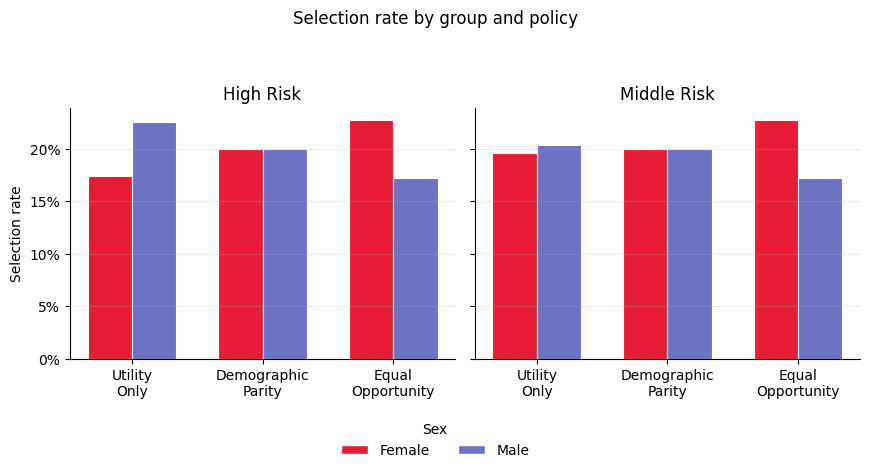

In [282]:

plot_static_selection_bars_1x2(
    source_df=eval_df,
    static_policy_cols=static_policy_cols,
    value_col="selection_rate",
    ylabel="Selection rate",
    title="Selection rate by group and policy"
)

*Among people who need support, does each group receive support at a similar rate?*

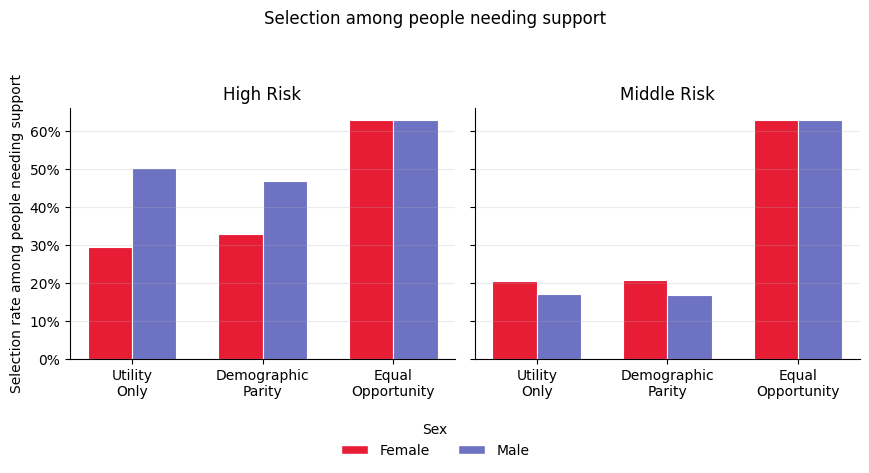

In [283]:
need_df = eval_df[eval_df["needs_support"] == 1]

plot_static_selection_bars_1x2(
    source_df=need_df,
    static_policy_cols=static_policy_cols,
    value_col="selection_given_need",
    ylabel="Selection rate among people needing support",
    title="Selection among people needing support"
)

In [285]:
eval_df.groupby("SEX_label").agg(
    n=("unemployment_risk", "size"),
    mean_risk=("unemployment_risk", "mean"),
    p30=("unemployment_risk", lambda x: x.quantile(0.30)),
    p40=("unemployment_risk", lambda x: x.quantile(0.40)),
    p50=("unemployment_risk", lambda x: x.quantile(0.50)),
    p60=("unemployment_risk", lambda x: x.quantile(0.60)),
    p70=("unemployment_risk", lambda x: x.quantile(0.70)),
    p80=("unemployment_risk", lambda x: x.quantile(0.80)),
    p90=("unemployment_risk", lambda x: x.quantile(0.90)),
    p95=("unemployment_risk", lambda x: x.quantile(0.95)),
    needs_support_rate=("needs_support", "mean")
)

,n,mean_risk,p30,p40,p50,p60,p70,p80,p90,p95,needs_support_rate
SEX_label,,,,,,,,,,,
Female,23372,0.304991,0.202352,0.231034,0.266474,0.305356,0.344167,0.399403,0.520251,0.672716,0.361843
Male,23570,0.330682,0.213626,0.250137,0.291830,0.330841,0.370081,0.441995,0.592308,0.736829,0.274077


In [286]:
def debug_middle_risk_capacity(df, group_col="SEX_label", budget=0.30,
                               middle_low=0.30, middle_high=0.70):

    low_q = df["unemployment_risk"].quantile(middle_low)
    high_q = df["unemployment_risk"].quantile(middle_high)

    rows = []

    for group_value, group_df in df.groupby(group_col):
        eligible = group_df[
            (group_df["unemployment_risk"] >= low_q) &
            (group_df["unemployment_risk"] <= high_q)
        ]

        nominal_quota = int(len(group_df) * budget)
        effective_quota = min(nominal_quota, len(eligible))

        rows.append({
            "group": group_value,
            "group_size": len(group_df),
            "eligible_middle": len(eligible),
            "nominal_quota": nominal_quota,
            "effective_quota": effective_quota,
            "eligible_share_group": len(eligible) / len(group_df),
            "quota_filled": effective_quota / nominal_quota if nominal_quota > 0 else np.nan
        })

    return pd.DataFrame(rows)

debug_middle_risk_capacity(eval_df, budget=0.30)

,group,group_size,eligible_middle,nominal_quota,effective_quota,eligible_share_group,quota_filled
0,Female,23372,9595,7011,7011,0.410534,1.0
1,Male,23570,9185,7071,7071,0.389690,1.0


#### Capacity sensitivity

In [287]:
###mean unemployment risk among selected people

def run_static_capacity_experiment(
    eval_df,
    budgets=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    group_col="SEX",
    group_label_col="SEX_label",
    seed=42
):
    rows = []

    for budget in budgets:
        rng = np.random.default_rng(seed)

        temp_df = eval_df.copy()

        # Recreate all policy columns at this budget
        temp_df = allocate_utility_only(
            temp_df,
            budget=budget,
            targeting="high_risk",
            rng=rng
        )

        temp_df = allocate_utility_only(
            temp_df,
            budget=budget,
            targeting="middle_risk",
            rng=rng
        )

        temp_df = allocate_demographic_parity(
            temp_df,
            group_col=group_col,
            budget=budget,
            targeting="high_risk",
            rng=rng
        )

        temp_df = allocate_demographic_parity(
            temp_df,
            group_col=group_col,
            budget=budget,
            targeting="middle_risk",
            rng=rng
        )

        temp_df = allocate_equal_opportunity(
            temp_df,
            group_col=group_col,
            budget=budget,
            targeting="high_risk",
            rng=rng
        )

        temp_df = allocate_equal_opportunity(
            temp_df,
            group_col=group_col,
            budget=budget,
            targeting="middle_risk",
            rng=rng
        )

        policy_cols = {
            "Utility Only": {
                "high_risk": "selected_utility_hr",
                "middle_risk": "selected_utility_mr"
            },
            "Demographic Parity": {
                "high_risk": "selected_dp_hr",
                "middle_risk": "selected_dp_mr"
            },
            "Equal Opportunity": {
                "high_risk": "selected_eo_hr",
                "middle_risk": "selected_eo_mr"
            }
        }

        for policy_name, targeting_dict in policy_cols.items():
            for targeting, selected_col in targeting_dict.items():

                selected_df = temp_df[temp_df[selected_col] == 1].copy()

                group_summary = (selected_df
                    .groupby([group_col, group_label_col])
                    .agg(
                        mean_selected_unemployment_risk=("unemployment_risk", "mean"),
                        mean_selected_employment_prob=("employment_prob", "mean"),
                        n_selected=(selected_col, "sum"),
                        share_selected_who_need_support=("needs_support", "mean"),
                        min_selected_risk=("unemployment_risk", "min"),
                        max_selected_risk=("unemployment_risk", "max")
                    )
                    .reset_index()
                )

                group_summary["budget"] = budget
                group_summary["policy"] = policy_name
                group_summary["targeting"] = targeting
                group_summary["selected_col"] = selected_col

                rows.append(group_summary)

    return pd.concat(rows, ignore_index=True)

In [288]:
budgets = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

static_capacity_results = run_static_capacity_experiment(
    eval_df=eval_df,
    budgets=budgets,
    group_col="SEX",
    group_label_col="SEX_label",
    seed=42
)

static_capacity_results.head()

,SEX,SEX_label,mean_selected_unemployment_risk,mean_selected_employment_prob,n_selected,share_selected_who_need_support,min_selected_risk,max_selected_risk,budget,policy,targeting,selected_col
0,1.0,Male,0.833614,0.166386,1373,0.831755,0.708342,0.976199,0.05,Utility Only,high_risk,selected_utility_hr
1,2.0,Female,0.821866,0.178134,974,0.821355,0.708085,0.967698,0.05,Utility Only,high_risk,selected_utility_hr
2,1.0,Male,0.346367,0.653633,1261,0.273592,0.336898,0.357019,0.05,Utility Only,middle_risk,selected_utility_mr
3,2.0,Female,0.346354,0.653646,1086,0.378453,0.336886,0.356885,0.05,Utility Only,middle_risk,selected_utility_mr
4,1.0,Male,0.852153,0.147847,1178,0.842954,0.736994,0.976199,0.05,Demographic Parity,high_risk,selected_dp_hr


In [289]:
def plot_static_capacity_1x2_clean(
    static_capacity_results,
    y_col="mean_selected_unemployment_risk"
):
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter

    targetings = ["high_risk", "middle_risk"]
    targeting_labels = {
        "high_risk": "High Risk",
        "middle_risk": "Middle Risk"
    }

    policy_order = ["Utility Only", "Demographic Parity", "Equal Opportunity"]
    policy_colors = {
        "Utility Only": "#23b5cc",#"#65DEF1",
        "Demographic Parity": "red",
        "Equal Opportunity": "navy"
    }

    cat_order = ["Female", "Male"]
    cat_styles = {
        "Female": "-",
        "Male": "--"
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 6),
        sharey=True
    )

    for ax, targeting in zip(axes, targetings):
        plot_df = static_capacity_results[
            static_capacity_results["targeting"] == targeting
        ].copy()

        for policy in policy_order:
            for cat_label in cat_order:
                group_df = plot_df[
                    (plot_df["policy"] == policy)
                    & (plot_df["SEX_label"] == cat_label)
                ].sort_values("budget")

                if group_df.empty:
                    continue

                ax.plot(
                    group_df["budget"],
                    group_df[y_col],
                    marker="o",
                    markersize=4.5,
                    linewidth=1,
                    color=policy_colors.get(policy, "#666666"),
                    linestyle=cat_styles.get(cat_label, "-"),
                    label=f"{policy} - {cat_label}"
                )

        ax.set_title(targeting_labels[targeting])
        ax.set_xlabel("PES capacity")
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.grid(alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mean unemployment risk among selected")

    policy_handles = [
        Line2D(
            [0],
            [0],
            color=policy_colors[policy],
            linewidth=1.5,
            label=policy
        )
        for policy in policy_order
    ]

    cat_handles = [
        Line2D(
            [0],
            [0],
            color="#333333",
            linewidth=1.5,
            linestyle=cat_styles[cat],
            label=cat
        )
        for cat in cat_order
    ]

    fig.suptitle("Static allocation under different PES capacity levels", y=0.98)
    fig.tight_layout(rect=[0, 0.18, 1, 0.93])

    fig.legend(
        handles=policy_handles,
        title="Policy",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.075),
        ncol=3,
        frameon=False
    )

    fig.legend(
        handles=cat_handles,
        title="Sex",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=2,
        frameon=False
    )

    plt.show()

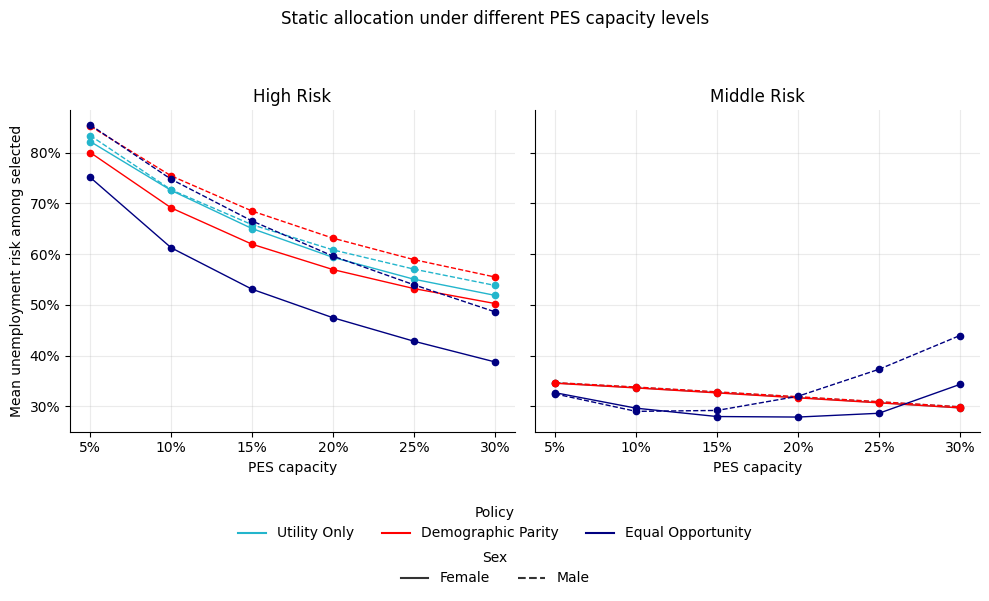

In [290]:
plot_static_capacity_1x2_clean(static_capacity_results)

In [205]:
static_capacity_gap = (
    static_capacity_results
    .groupby(["policy", "targeting", "budget"])
    .agg(
        risk_gap=("mean_selected_unemployment_risk", lambda x: x.max() - x.min()),
        selected_need_gap=("share_selected_who_need_support", lambda x: x.max() - x.min())
    )
    .reset_index()
)

In [206]:
def plot_static_capacity_gap_1x2(static_capacity_gap):
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter

    targetings = ["high_risk", "middle_risk"]
    targeting_labels = {
        "high_risk": "High Risk",
        "middle_risk": "Middle Risk"
    }

    policy_order = ["Utility Only", "Demographic Parity", "Equal Opportunity"]
    policy_colors = {
        "Utility Only": "#23b5cc",
        "Demographic Parity": "red",
        "Equal Opportunity": "navy"
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.2, 4.4),
        sharey=True
    )

    for ax, targeting in zip(axes, targetings):
        plot_df = static_capacity_gap[
            static_capacity_gap["targeting"] == targeting
        ].copy()

        for policy in policy_order:
            group_df = plot_df[
                plot_df["policy"] == policy
            ].sort_values("budget")

            if group_df.empty:
                continue

            ax.plot(
                group_df["budget"],
                group_df["risk_gap"],
                color=policy_colors.get(policy, "#666666"),
                marker="o",
                markersize=4.5,
                linewidth=2,
                label=policy
            )

        ax.set_title(targeting_labels[targeting])
        ax.set_xlabel("PES capacity")
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.grid(alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Gap in selected unemployment risk")

    policy_handles = [
        Line2D(
            [0],
            [0],
            color=policy_colors[policy],
            marker="o",
            markersize=4.5,
            linewidth=2,
            label=policy
        )
        for policy in policy_order
    ]

    fig.suptitle("Selected-risk gap as PES capacity increases", y=0.98)
    fig.tight_layout(rect=[0, 0.12, 1, 0.92])

    fig.legend(
        handles=policy_handles,
        title="Policy",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=3,
        frameon=False
    )

    plt.show()

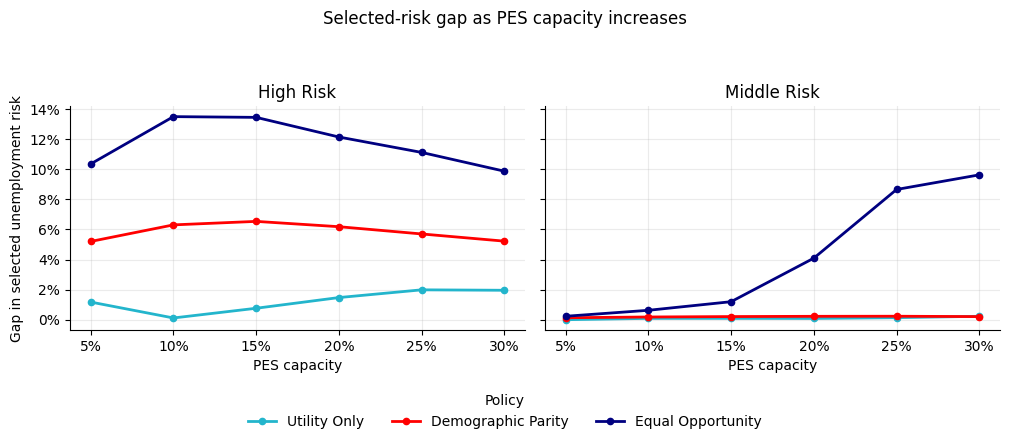

In [207]:
plot_static_capacity_gap_1x2(static_capacity_gap)

In [208]:
capacity_debug = (
    static_capacity_results
    .groupby(["budget", "policy", "targeting"])
    .agg(
        total_selected=("n_selected", "sum"),
        mean_risk=("mean_selected_unemployment_risk", "mean"),
        min_group_risk=("mean_selected_unemployment_risk", "min"),
        max_group_risk=("mean_selected_unemployment_risk", "max"),
        risk_gap=("mean_selected_unemployment_risk", lambda x: x.max() - x.min()),
        mean_share_need=("share_selected_who_need_support", "mean")
    )
    .reset_index()
)

capacity_debug

,budget,policy,targeting,total_selected,mean_risk,min_group_risk,max_group_risk,risk_gap,mean_share_need
0,0.05,Demographic Parity,high_risk,2346,0.826142,0.800132,0.852153,0.052022,0.821306
1,0.05,Demographic Parity,middle_risk,2346,0.346326,0.345665,0.346986,0.001321,0.328874
2,0.05,Equal Opportunity,high_risk,2347,0.802862,0.751097,0.854627,0.103529,1.000000
3,0.05,Equal Opportunity,middle_risk,2347,0.325872,0.324718,0.327025,0.002307,1.000000
4,0.05,Utility Only,high_risk,2347,0.827740,0.821866,0.833614,0.011748,0.826555
5,0.05,Utility Only,middle_risk,2347,0.346361,0.346354,0.346367,0.000014,0.326023
6,0.10,Demographic Parity,high_risk,4694,0.722648,0.691131,0.754166,0.063035,0.735882
7,0.10,Demographic Parity,middle_risk,4694,0.337319,0.336407,0.338230,0.001823,0.328353
8,0.10,Equal Opportunity,high_risk,4694,0.680030,0.612545,0.747515,0.134971,1.000000
9,0.10,Equal Opportunity,middle_risk,4694,0.293432,0.290296,0.296568,0.006271,1.000000


In [209]:
def compare_selected_sets(df, col_a, col_b):
    a = set(df.index[df[col_a] == 1])
    b = set(df.index[df[col_b] == 1])

    return {
        "col_a": col_a,
        "col_b": col_b,
        "n_a": len(a),
        "n_b": len(b),
        "overlap": len(a & b),
        "overlap_pct_of_a": len(a & b) / len(a) if len(a) > 0 else np.nan,
        "overlap_pct_of_b": len(a & b) / len(b) if len(b) > 0 else np.nan
    }

compare_selected_sets(eval_df, "selected_utility_mr", "selected_dp_mr")

{'col_a': 'selected_utility_mr',
 'col_b': 'selected_dp_mr',
 'n_a': 7041,
 'n_b': 7040,
 'overlap': 6969,
 'overlap_pct_of_a': 0.9897741798040051,
 'overlap_pct_of_b': 0.9899147727272727}

In [210]:
compare_selected_sets(eval_df, "selected_utility_hr", "selected_dp_hr")

{'col_a': 'selected_utility_hr',
 'col_b': 'selected_dp_hr',
 'n_a': 7041,
 'n_b': 7040,
 'overlap': 6483,
 'overlap_pct_of_a': 0.9207498934810396,
 'overlap_pct_of_b': 0.9208806818181818}

In [211]:
compare_selected_sets(eval_df, "selected_eo_hr", "selected_utility_hr")


{'col_a': 'selected_eo_hr',
 'col_b': 'selected_utility_hr',
 'n_a': 7041,
 'n_b': 7041,
 'overlap': 4728,
 'overlap_pct_of_a': 0.6714955262036643,
 'overlap_pct_of_b': 0.6714955262036643}

In [212]:
compare_selected_sets(eval_df, "selected_eo_mr", "selected_utility_mr")

{'col_a': 'selected_eo_mr',
 'col_b': 'selected_utility_mr',
 'n_a': 7041,
 'n_b': 7041,
 'overlap': 2162,
 'overlap_pct_of_a': 0.30705865644084646,
 'overlap_pct_of_b': 0.30705865644084646}

The static capacity experiment does not model program effects. It only shows how different allocation rules and targeting strategies change the risk profile of selected individuals as PES capacity increases. This is a simplified analogue of Zezulka’s capacity analysis, focused on allocation rather than program assignment.

### Long-term allocation

Demographic parity almost removes the selection-rate gap, but disparities remain among people who actually need support.

In [213]:
def select_by_targeting(
    df,
    score_col,
    n_select,
    targeting="high_risk",
    middle_low=0.30,
    middle_high=0.70,
    rng=None,
    risk_col="current_risk",
    middle_low_q=None,
    middle_high_q=None
):
    if rng is None:
        rng = np.random.default_rng(42)

    if n_select <= 0:
        return []

    if targeting == "high_risk":
        return (
            df.sort_values(score_col, ascending=False)
              .head(n_select)
              .index
              .tolist()
        )

    elif targeting == "middle_risk":

        if middle_low_q is None or middle_high_q is None:
            middle_low_q = df[risk_col].quantile(middle_low)
            middle_high_q = df[risk_col].quantile(middle_high)

        eligible = df[
            (df[risk_col] >= middle_low_q) &
            (df[risk_col] <= middle_high_q)
        ].copy()

        n_select = min(n_select, len(eligible))

        if n_select == 0:
            return []

        return (
            eligible.sort_values(score_col, ascending=False)
                    .head(n_select)
                    .index
                    .tolist()
        )

    else:
        raise ValueError("targeting must be 'high_risk' or 'middle_risk'")

In [ ]:
# Dynamic allocation function

def allocate_support_dynamic(
    df,
    policy,
    budget=0.30,
    group_col="SEX",
    lambda_fairness=0.10,
    benefit_rates_so_far=None,
    targeting="high_risk",
    middle_low=0.30,
    middle_high=0.70,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng(42)

    df = df.copy()

    # only people currently needing support should be eligible
    eligible_df = df[df["current_need"] == 1].copy()

    n_select = int(len(eligible_df) * budget)

    df["selected"] = 0
    df["current_risk"] = 1 - df["current_employment_prob"]

    if len(eligible_df) == 0 or n_select == 0:
        return df

    eligible_df["current_risk"] = 1 - eligible_df["current_employment_prob"]

    middle_low_q = None
    middle_high_q = None

    if targeting == "middle_risk":
        middle_low_q = eligible_df["current_risk"].quantile(middle_low)
        middle_high_q = eligible_df["current_risk"].quantile(middle_high)

    if policy == "utility_only":
        selected_idx = select_by_targeting(
            eligible_df,
            score_col="current_risk",
            n_select=n_select,
            targeting=targeting,
            middle_low=middle_low,
            middle_high=middle_high,
            rng=rng,
            middle_low_q = middle_low_q,
            middle_high_q = middle_high_q
        )

    elif policy == "static_dp":
         selected_idx = []

         for group_value, group_df in eligible_df.groupby(group_col):
            n_group_select = int(len(group_df) * budget)

            group_selected_idx = select_by_targeting(
                group_df,
                score_col="current_risk",
                n_select=n_group_select,
                targeting=targeting,
                middle_low=middle_low,
                middle_high=middle_high,
                rng=rng,
                risk_col="current_risk",
                middle_low_q=middle_low_q,
                middle_high_q=middle_high_q
            )

            selected_idx.extend(group_selected_idx)

    elif policy == "static_eo":
        selected_idx = []

        
        # equal allocation rate among people who currently need support.
        # current_need = demand.
        for group_value, group_df in eligible_df.groupby(group_col):
            n_group_select = int(len(group_df) * budget)

            group_selected_idx = select_by_targeting(
                group_df,
                score_col="current_risk",
                n_select=n_group_select,
                targeting=targeting,
                middle_low=middle_low,
                middle_high=middle_high,
                rng=rng
            )

            selected_idx.extend(group_selected_idx)

    elif policy == "long_term_aware":
        if benefit_rates_so_far is None:
            benefit_rates_so_far = {
                group_value: 0 for group_value in eligible_df[group_col].unique()
            }

        max_benefit_rate = max(benefit_rates_so_far.values())

        group_deficits = {
            group_value: max_benefit_rate - benefit_rate
            for group_value, benefit_rate in benefit_rates_so_far.items()
        }

        eligible_df["group_deficit"] = (
            eligible_df[group_col].map(group_deficits).fillna(0)
        )

        eligible_df["adjusted_score"] = (
            eligible_df["current_risk"] +
            lambda_fairness * eligible_df["group_deficit"]
        )

        selected_idx = select_by_targeting(
        eligible_df,
        score_col="adjusted_score",
        n_select=n_select,
        targeting=targeting,
        middle_low=middle_low,
        middle_high=middle_high,
        rng=rng,
        risk_col="current_risk",
        middle_low_q=middle_low_q,
        middle_high_q=middle_high_q
    )

    else:
        raise ValueError(
            "policy must be: 'utility_only', 'static_dp', 'static_eo', or 'long_term_aware'"
        )

    df.loc[selected_idx, "selected"] = 1

    return df

In [ ]:
# Refill the active population after exits

def refill_exited_people(
    df,
    base_df,
    employed_mask,
    rng,
    reset_as_job_seekers=False
):
    df = df.copy()

    n_replace = employed_mask.sum()

    if n_replace == 0:
        return df

    replacement_rows = base_df.sample(
        n=n_replace,
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).copy()

    replacement_rows.index = df.loc[employed_mask].index

    # reset dynamic state from the full background/evaluation population
    replacement_rows["current_employment_prob"] = replacement_rows["employment_prob"]

    if reset_as_job_seekers:
        replacement_rows["current_employed"] = 0
        replacement_rows["current_need"] = 1
    else:
        replacement_rows["current_employed"] = replacement_rows["y_true"]
        replacement_rows["current_need"] = 1 - replacement_rows["current_employed"]

    replacement_rows["unemployment_duration"] = 0
    replacement_rows["cumulative_demand"] = 0
    replacement_rows["cumulative_benefit"] = 0
    replacement_rows["cumulative_support"] = 0
    replacement_rows["selected"] = 0
    replacement_rows["new_employed"] = replacement_rows["current_employed"]
    replacement_rows["timed_out"] = 0
    replacement_rows["benefit_this_round"] = 0
    replacement_rows["demand_this_round"] = replacement_rows["current_need"]

    for col in replacement_rows.columns:
        if col in df.columns:
            df.loc[employed_mask, col] = replacement_rows[col]

    return df

In [ ]:
def draw_support_effects(
    df,
    rng,
    base_effect=0.04,
    strong_effect=0.10,
    strong_program_share=0.25,
    noise_sd=0.01
):
    effects = np.zeros(len(df))

    selected_mask = df["selected"].values == 1
    n_selected = selected_mask.sum()

    if n_selected == 0:
        return effects

    strong_program = rng.binomial(
        n=1,
        p=strong_program_share,
        size=n_selected
    )

    selected_effects = np.where(
        strong_program == 1,
        strong_effect,
        base_effect
    )

    selected_effects = selected_effects + rng.normal(
        loc=0,
        scale=noise_sd,
        size=n_selected
    )

    selected_effects = np.clip(selected_effects, 0, None)

    effects[selected_mask] = selected_effects

    return effects


*   benefit = 1 if selected and becomes employed
*   demand = 1 if person needs support




#### Optional sensitivity checks

The following parameters can be varied to explore the sensitivity of the dynamic simulation:

- `lambda_fairness`: controls the fairness penalty for the `long_term_aware` policy. Example values: `0.5`, `2`, and `5`.
- `base_effect` and `strong_effect`: control the magnitude of the simulated program effects when `variable_support_effect=True`.
- `max_unemployment_duration`: controls the number of consecutive unemployed rounds before an individual times out of the active pool.

Change one parameter at a time to preserve interpretable comparisons. Budget sensitivity is evaluated separately in the static experiments above.

#### Dynamic simulation

In [ ]:
def run_dynamic_simulation(
    base_df,
    policy,
    T=20,
    budget=0.30,
    support_effect=0.05,
    no_support_decay=0.01,
    lambda_fairness=0.10,
    group_col="SEX",
    group_label_col="SEX_label",
    seed=42,
    targeting="high_risk",
    middle_low=0.30,
    middle_high=0.70,
    refill_pool=True,
    variable_support_effect=True,
    base_effect=0.04,
    strong_effect=0.1,
    strong_program_share=0.25,
    support_noise_sd=0.01,
    max_unemployment_duration=6
):
    rng = np.random.default_rng(seed)

    df = base_df.copy()

  
# Not everyone is currently in need; need is defined by current_employed == 0.
    df["current_employment_prob"] = df["employment_prob"].copy()
    df["current_employed"] = df["y_true"].copy()
    df["current_need"] = 1 - df["current_employed"]
    df["unemployment_duration"] = 0

    # Cumulative counters for current individuals in the pool
    df["cumulative_demand"] = 0
    df["cumulative_benefit"] = 0
    df["cumulative_support"] = 0

    results = []

    global_history = {
    group_value: {"demand": 0, "benefit": 0, "support": 0}
    for group_value in df[group_col].unique()
}

    for t in range(1, T + 1):

        # Benefit rates so far
        benefit_rates_so_far = {}

        for group_value, hist in global_history.items():
            benefit_rates_so_far[group_value] = (
                hist["benefit"] / hist["demand"]
                if hist["demand"] > 0 else 0
            )

        # risk before policy intervention in this round
        df["risk_before_support"] = 1 - df["current_employment_prob"]

        allocated_df = allocate_support_dynamic(
            df=df,
            policy=policy,
            budget=budget,
            group_col=group_col,
            lambda_fairness=lambda_fairness,
            benefit_rates_so_far=benefit_rates_so_far,
            targeting=targeting,
            middle_low=middle_low,
            middle_high=middle_high,
            rng=rng
        )

        df["selected"] = allocated_df["selected"]

        # Need before support
        df["need_before_support"] = df["current_need"]

        if variable_support_effect:
            individual_support_effect = draw_support_effects(
                df=df,
                rng=rng,
                base_effect=base_effect,
                strong_effect=strong_effect,
                strong_program_share=strong_program_share,
                noise_sd=support_noise_sd
            )
        else:
            individual_support_effect = df["selected"].values * support_effect

        # update 
        unsupported_need = (
            (df["need_before_support"] == 1) &
            (df["selected"] == 0)
        )

        df["current_employment_prob"] = (
            df["current_employment_prob"] +
            individual_support_effect -
            np.where(unsupported_need, no_support_decay, 0)
        )



        df["current_employment_prob"] = df["current_employment_prob"].clip(0, 1)

        # employment outcome
        df["new_employed"] = rng.binomial(
            n=1,
            p=df["current_employment_prob"]
        )

        # update state after outcome
        df["current_employed"] = df["new_employed"]
        df["current_need"] = 1 - df["current_employed"]

        # unemployed accumulate duration
        df["unemployment_duration"] = np.where(
        df["current_need"] == 1,
        df["unemployment_duration"] + 1,
        0
    )

        df["timed_out"] = (
            (df["current_need"] == 1) &
            (df["unemployment_duration"] >= max_unemployment_duration)
        ).astype(int)

        # benefit = needed support, received support, became employed
        df["benefit_this_round"] = (
            (df["selected"] == 1) &
            (df["need_before_support"] == 1) &
            (df["new_employed"] == 1)
        ).astype(int)

        # dem = needed support in this round
        df["demand_this_round"] = df["need_before_support"]

        need_mask = df["need_before_support"] == 1
        selected_need_mask = (df["selected"] == 1) & (df["need_before_support"] == 1)

        avg_risk_among_need = (
            df.loc[need_mask, "risk_before_support"].mean()
            if need_mask.sum() > 0 else np.nan
        )

        avg_risk_supported = (
            df.loc[selected_need_mask, "risk_before_support"].mean()
            if selected_need_mask.sum() > 0 else np.nan
        )

        job_finding_rate_among_need = (
            df.loc[need_mask, "new_employed"].mean()
            if need_mask.sum() > 0 else np.nan
        )

        job_finding_rate_supported = (
            df.loc[selected_need_mask, "new_employed"].mean()
            if selected_need_mask.sum() > 0 else np.nan
        )

        support_coverage_rate = (
            df.loc[need_mask, "selected"].mean()
            if need_mask.sum() > 0 else np.nan
        )


        timeout_rate = df["timed_out"].mean()
        exit_rate = ((df["new_employed"] == 1) | (df["timed_out"] == 1)).mean()

        for group_value, group_df in df.groupby(group_col):
            global_history[group_value]["demand"] += group_df["demand_this_round"].sum()
            global_history[group_value]["benefit"] += group_df["benefit_this_round"].sum()
            global_history[group_value]["support"] += group_df["selected"].sum()

        # updt
        df["cumulative_demand"] += df["demand_this_round"]
        df["cumulative_benefit"] += df["benefit_this_round"]
        df["cumulative_support"] += df["selected"]

        #metrics
        group_summary = (
        df.groupby([group_col, group_label_col])
        .agg(
            n=("selected", "size"),

            need_count=("need_before_support", "sum"),
            selected_count=("selected", "sum"),
            job_found_count=("new_employed", "sum"),
            benefit_count=("benefit_this_round", "sum"),
            demand_this_round_count=("demand_this_round", "sum"),
            employment_rate=("new_employed", "mean"),
            selection_rate=("selected", "mean"),
            avg_employment_prob=("current_employment_prob", "mean"),
            avg_risk_group=("risk_before_support", "mean"),
            cumulative_demand=("cumulative_demand", "sum"),
            cumulative_benefit=("cumulative_benefit", "sum"),
            cumulative_support=("cumulative_support", "sum")
        )
        .reset_index()
        )

        need_by_group = (
            df[df["need_before_support"] == 1]
            .groupby([group_col, group_label_col])
            .agg(
                job_finding_rate_among_need_group=("new_employed", "mean"),
                selection_rate_among_need_group=("selected", "mean"),
                avg_risk_among_need_group=("risk_before_support", "mean")
            )
            .reset_index()
        )

        supported_by_group = (
            df[(df["selected"] == 1) & (df["need_before_support"] == 1)]
            .groupby([group_col, group_label_col])
            .agg(
                job_finding_rate_supported_group=("new_employed", "mean"),
                avg_risk_supported_group=("risk_before_support", "mean")
            )
            .reset_index()
        )

        group_summary = group_summary.merge(
            need_by_group,
            on=[group_col, group_label_col],
            how="left"
        )

        group_summary = group_summary.merge(
            supported_by_group,
            on=[group_col, group_label_col],
            how="left"
        )

        group_summary["cumulative_demand_global"] = group_summary[group_col].map(
            lambda g: global_history[g]["demand"]
        )

        group_summary["cumulative_benefit_global"] = group_summary[group_col].map(
            lambda g: global_history[g]["benefit"]
        )

        group_summary["cumulative_support_global"] = group_summary[group_col].map(
            lambda g: global_history[g]["support"]
        )

        group_summary["benefit_rate"] = np.where(
            group_summary["cumulative_demand_global"] > 0,
            group_summary["cumulative_benefit_global"] / group_summary["cumulative_demand_global"],
            0
        )

        group_summary["support_rate_cumulative"] = np.where(
            group_summary["cumulative_demand_global"] > 0,
            group_summary["cumulative_support_global"] / group_summary["cumulative_demand_global"],
            0
        )

        employment_gap = (
            group_summary["employment_rate"].max() -
            group_summary["employment_rate"].min()
        )

 
        job_finding_gap = (
            group_summary["job_finding_rate_among_need_group"].max() -
            group_summary["job_finding_rate_among_need_group"].min()
        )

        benefit_rate_gap = (
            group_summary["benefit_rate"].max() -
            group_summary["benefit_rate"].min()
        )

        selection_rate_gap = (
            group_summary["selection_rate"].max() -
            group_summary["selection_rate"].min()
        )

        support_rate_gap = (
            group_summary["support_rate_cumulative"].max() -
            group_summary["support_rate_cumulative"].min()
        )

        total_employment = df["new_employed"].mean()
        total_benefit = df["benefit_this_round"].sum()

        group_summary["round"] = t
        group_summary["policy"] = policy
        group_summary["targeting"] = targeting
        group_summary["policy_variant"] = policy + "_" + targeting

        group_summary["employment_gap"] = employment_gap
        group_summary["benefit_rate_gap"] = benefit_rate_gap
        group_summary["selection_rate_gap"] = selection_rate_gap
        group_summary["support_rate_gap"] = support_rate_gap
        group_summary["total_employment_rate"] = total_employment
        group_summary["total_benefit"] = total_benefit

        group_summary["timeout_rate"] = timeout_rate
        group_summary["exit_rate"] = exit_rate
        group_summary["avg_employment_prob_total"] = df["current_employment_prob"].mean()
        group_summary["job_finding_rate_among_need"] = job_finding_rate_among_need
        group_summary["job_finding_rate_supported"] = job_finding_rate_supported
        group_summary["support_coverage_rate"] = support_coverage_rate

        group_summary["avg_risk_among_need"] = avg_risk_among_need
        group_summary["avg_risk_supported"] = avg_risk_supported
        group_summary["job_finding_gap"] = job_finding_gap

        results.append(group_summary)

        # found jobs leave 
        exit_mask = (df["new_employed"] == 1) | (df["timed_out"] == 1)

        if refill_pool:
            df = refill_exited_people(
                df=df,
                base_df=base_df,
                employed_mask=exit_mask,
                rng=rng,
                reset_as_job_seekers=False
            )

            df.loc[exit_mask, "unemployment_duration"] = 0
        else:
            df["current_employed"] = df["new_employed"]
            df["current_need"] = 1 - df["current_employed"]

    results_df = pd.concat(results, ignore_index=True)

    return results_df

In [218]:
from joblib import Parallel, delayed

def run_one_simulation_combo(
    base_df,
    policy,
    targeting,
    seed,
    T,
    budget,
    support_effect,
    no_support_decay,
    lambda_fairness,
    group_col,
    group_label_col,
    refill_pool,
    variable_support_effect,
    max_unemployment_duration,
    base_effect=0.025,
    strong_effect=0.05,
    strong_program_share=0.25,
    support_noise_sd=0.01
):
    result = run_dynamic_simulation(
        base_df=base_df,
        policy=policy,
        T=T,
        budget=budget,
        support_effect=support_effect,
        no_support_decay=no_support_decay,
        lambda_fairness=lambda_fairness,
        group_col=group_col,
        group_label_col=group_label_col,
        seed=seed,
        targeting=targeting,
        refill_pool=refill_pool,
        variable_support_effect=variable_support_effect,
        max_unemployment_duration=max_unemployment_duration,
        base_effect=base_effect,
        strong_effect=strong_effect,
        strong_program_share=strong_program_share,
        support_noise_sd=support_noise_sd
    )

    result["seed"] = seed
    return result


def run_multiple_simulations_parallel(
    base_df,
    policies,
    seeds,
    targeting_scenarios,
    T=20,
    budget=0.30,
    support_effect=0.05,
    no_support_decay=0.01,
    lambda_fairness=2,
    group_col="SEX",
    group_label_col="SEX_label",
    refill_pool=True,
    variable_support_effect=True,
    max_unemployment_duration=6,
    base_effect=0.025,
    strong_effect=0.05,   
    n_jobs=-1
):
    combos = [
        (policy, targeting, seed)
        for seed in seeds
        for policy in policies
        for targeting in targeting_scenarios
    ]

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(run_one_simulation_combo)(
            base_df,
            policy,
            targeting,
            seed,
            T,
            budget,
            support_effect,
            no_support_decay,
            lambda_fairness,
            group_col,
            group_label_col,
            refill_pool,
            variable_support_effect,
            max_unemployment_duration, 
            base_effect,
            strong_effect,
        )
        for policy, targeting, seed in combos
    )

    return pd.concat(results, ignore_index=True)

In [219]:
dynamic_results_multi = run_multiple_simulations_parallel(
    base_df=eval_df,
    policies=["utility_only", "static_dp","long_term_aware"],
    seeds=range(50),
    targeting_scenarios=["high_risk", "middle_risk"],
    T=12,
    budget=0.20,
    support_effect=0.05,
    no_support_decay=0.01,
    lambda_fairness=0.5,
    group_col="SEX",
    group_label_col="SEX_label",
    refill_pool=True,
    variable_support_effect=True,
    max_unemployment_duration=6,
    base_effect=0.03,
    strong_effect=0.05, 
    n_jobs=-1
)

In [220]:
run_level_results = (
    dynamic_results_multi
    .drop_duplicates(["policy_variant", "round", "seed"])
)

In [221]:
gap_over_time_avg = (
    run_level_results
    .groupby(["policy_variant", "round"])
    .agg(
        employment_gap_mean=("employment_gap", "mean"),
        employment_gap_sd=("employment_gap", "std"),
        benefit_rate_gap_mean=("benefit_rate_gap", "mean"),
        benefit_rate_gap_sd=("benefit_rate_gap", "std"),
        selection_rate_gap_mean=("selection_rate_gap", "mean"),
        selection_rate_gap_sd=("selection_rate_gap", "std"),
        support_rate_gap_mean=("support_rate_gap", "mean"),
        support_rate_gap_sd=("support_rate_gap", "std"),
        total_employment_rate_mean=("total_employment_rate", "mean"),
        total_employment_rate_sd=("total_employment_rate", "std"),
        timeout_rate_mean=("timeout_rate", "mean"),
        timeout_rate_sd=("timeout_rate", "std"),
        exit_rate_mean=("exit_rate", "mean"),
        exit_rate_sd=("exit_rate", "std"),
        avg_employment_prob_mean=("avg_employment_prob_total", "mean"),
        avg_employment_prob_sd=("avg_employment_prob_total", "std"),
        job_finding_rate_among_need_mean=("job_finding_rate_among_need", "mean"),
        job_finding_rate_among_need_sd=("job_finding_rate_among_need", "std"),
        job_finding_rate_supported_mean=("job_finding_rate_supported", "mean"),
        job_finding_rate_supported_sd=("job_finding_rate_supported", "std"),
        support_coverage_rate_mean=("support_coverage_rate", "mean"),
        support_coverage_rate_sd=("support_coverage_rate", "std"),
        avg_risk_among_need_mean=("avg_risk_among_need", "mean"),
        avg_risk_among_need_sd=("avg_risk_among_need", "std"),
        avg_risk_supported_mean=("avg_risk_supported", "mean"),
        avg_risk_supported_sd=("avg_risk_supported", "std"),
        job_finding_gap_mean=("job_finding_gap", "mean"),
        job_finding_gap_sd=("job_finding_gap", "std"),
            )
    .reset_index()
)

In [222]:
dynamic_group_over_time_avg = (
    dynamic_results_multi
    .groupby(["policy_variant", "round", "SEX_label"], as_index=False)
    .agg(
        selection_rate_mean=("selection_rate", "mean"),
        selection_rate_sd=("selection_rate", "std"),

        selection_rate_among_need_mean=("selection_rate_among_need_group", "mean"),
        selection_rate_among_need_sd=("selection_rate_among_need_group", "std"),

        job_finding_rate_among_need_mean=("job_finding_rate_among_need_group", "mean"),
        job_finding_rate_among_need_sd=("job_finding_rate_among_need_group", "std"),

        job_finding_rate_supported_mean=("job_finding_rate_supported_group", "mean"),
        job_finding_rate_supported_sd=("job_finding_rate_supported_group", "std"),

        benefit_rate_mean=("benefit_rate", "mean"),
        benefit_rate_sd=("benefit_rate", "std"),

        support_rate_cumulative_mean=("support_rate_cumulative", "mean"),
        support_rate_cumulative_sd=("support_rate_cumulative", "std"),

        avg_risk_among_need_mean=("avg_risk_among_need_group", "mean"),
        avg_risk_among_need_sd=("avg_risk_among_need_group", "std"),

        avg_risk_supported_mean=("avg_risk_supported_group", "mean"),
        avg_risk_supported_sd=("avg_risk_supported_group", "std")
    )
)

In [223]:
pd.set_option('display.max_columns', None)

In [224]:
final_round = int(dynamic_results_multi["round"].max())

dynamic_group_final = (
    dynamic_group_over_time_avg[
        dynamic_group_over_time_avg["round"] == final_round
    ]
    .sort_values(["policy_variant", "SEX_label"])
)

dynamic_group_final

,policy_variant,round,SEX_label,selection_rate_mean,selection_rate_sd,selection_rate_among_need_mean,selection_rate_among_need_sd,job_finding_rate_among_need_mean,job_finding_rate_among_need_sd,job_finding_rate_supported_mean,job_finding_rate_supported_sd,benefit_rate_mean,benefit_rate_sd,support_rate_cumulative_mean,support_rate_cumulative_sd,avg_risk_among_need_mean,avg_risk_among_need_sd,avg_risk_supported_mean,avg_risk_supported_sd
22,long_term_aware_high_risk,12,Female,0.097028,0.001815,0.165745,0.002771,0.580758,0.003566,0.269956,0.007810,0.044367,0.000491,0.164693,0.001384,0.417923,0.002050,0.768724,0.002357
23,long_term_aware_high_risk,12,Male,0.128969,0.001670,0.234412,0.002753,0.517488,0.004643,0.251760,0.008983,0.060227,0.000676,0.236082,0.001351,0.482602,0.002344,0.782590,0.002467
46,long_term_aware_middle_risk,12,Female,0.111345,0.001482,0.189201,0.002381,0.557986,0.003421,0.566010,0.010469,0.110304,0.000789,0.190752,0.001011,0.439555,0.002052,0.466781,0.002254
47,long_term_aware_middle_risk,12,Male,0.117521,0.001610,0.210660,0.002356,0.484624,0.003833,0.553518,0.009029,0.118104,0.000580,0.209296,0.001025,0.514236,0.001929,0.480914,0.002319
70,static_dp_high_risk,12,Female,0.116712,0.000599,0.199971,0.000023,0.584082,0.004380,0.293495,0.008507,0.059865,0.000635,0.199969,0.000006,0.414783,0.001979,0.741295,0.003375
71,static_dp_high_risk,12,Male,0.110242,0.000639,0.199971,0.000021,0.512724,0.004569,0.231134,0.007973,0.046474,0.000592,0.199971,0.000006,0.485914,0.001750,0.803231,0.002299
94,static_dp_middle_risk,12,Female,0.117570,0.000553,0.199969,0.000020,0.559761,0.003943,0.573484,0.009100,0.116267,0.000625,0.199970,0.000005,0.439301,0.002081,0.461821,0.002293
95,static_dp_middle_risk,12,Male,0.111663,0.000648,0.199968,0.000021,0.484924,0.004065,0.550045,0.012143,0.112112,0.000710,0.199971,0.000006,0.513772,0.002202,0.485305,0.003424
118,utility_only_high_risk,12,Female,0.095205,0.001436,0.162698,0.002378,0.579733,0.003982,0.264454,0.008801,0.043017,0.000395,0.161123,0.001243,0.417890,0.001627,0.771043,0.002423
119,utility_only_high_risk,12,Male,0.130701,0.001633,0.237319,0.002416,0.518854,0.004600,0.254142,0.008219,0.061621,0.000726,0.239704,0.001233,0.482469,0.002056,0.781381,0.002210


In [225]:
timeout_post_threshold = (
    run_level_results[run_level_results['round']>=6]
    .groupby(["policy_variant"])
    .agg(
        timeout_rate_post_threshold_mean=("timeout_rate", "mean"),
        timeout_rate_post_threshold_sd=("timeout_rate", "std")
    )
    .reset_index()
)

In [226]:
timeout_post_threshold

,policy_variant,timeout_rate_post_threshold_mean,timeout_rate_post_threshold_sd
0,long_term_aware_high_risk,0.009442,0.001552
1,long_term_aware_middle_risk,0.019025,0.003912
2,static_dp_high_risk,0.009551,0.001633
3,static_dp_middle_risk,0.019014,0.003936
4,utility_only_high_risk,0.009419,0.001561
5,utility_only_middle_risk,0.019002,0.003995


In [227]:
final_round_summary_avg = (
    gap_over_time_avg[gap_over_time_avg["round"] == 12]
    [[
        "policy_variant",
        "employment_gap_mean",
        "employment_gap_sd",
        "benefit_rate_gap_mean",
        "benefit_rate_gap_sd",
        "selection_rate_gap_mean",
        "selection_rate_gap_sd",
        "support_rate_gap_mean",
        "support_rate_gap_sd",
        "total_employment_rate_mean",
        "total_employment_rate_sd",
        "timeout_rate_mean",
        "timeout_rate_sd",
        "exit_rate_mean",
        "exit_rate_sd",
        "avg_employment_prob_mean",
        "avg_employment_prob_sd",
        "job_finding_rate_among_need_mean",
        "job_finding_rate_among_need_sd",
        "job_finding_rate_supported_mean",
        "job_finding_rate_supported_sd",
        "support_coverage_rate_mean",
        "support_coverage_rate_sd",
        "avg_risk_among_need_mean",
        "avg_risk_among_need_sd",
        "avg_risk_supported_mean",
        "avg_risk_supported_sd",
        "job_finding_gap_mean",
        "job_finding_gap_sd",

    ]]
    .sort_values("benefit_rate_gap_mean")
)

final_round_summary_avg

,policy_variant,employment_gap_mean,employment_gap_sd,benefit_rate_gap_mean,benefit_rate_gap_sd,selection_rate_gap_mean,selection_rate_gap_sd,support_rate_gap_mean,support_rate_gap_sd,total_employment_rate_mean,total_employment_rate_sd,timeout_rate_mean,timeout_rate_sd,exit_rate_mean,exit_rate_sd,avg_employment_prob_mean,avg_employment_prob_sd,job_finding_rate_among_need_mean,job_finding_rate_among_need_sd,job_finding_rate_supported_mean,job_finding_rate_supported_sd,support_coverage_rate_mean,support_coverage_rate_sd,avg_risk_among_need_mean,avg_risk_among_need_sd,avg_risk_supported_mean,avg_risk_supported_sd,job_finding_gap_mean,job_finding_gap_sd
47,static_dp_middle_risk,0.042373,0.003857,0.004156,0.000952,0.005907,0.000905,0.000006,0.000005,0.608897,0.002091,0.017185,0.000540,0.626082,0.002075,0.609518,0.000749,0.522081,0.002834,0.561680,0.007925,0.199969,0.000016,0.476796,0.001234,0.473645,0.002645,0.074837,0.005677
23,long_term_aware_middle_risk,0.041655,0.004034,0.007800,0.001024,0.006264,0.002741,0.018544,0.002035,0.608599,0.001928,0.017263,0.000633,0.625863,0.001875,0.609499,0.000918,0.521124,0.002284,0.559423,0.007379,0.199984,0.000012,0.477080,0.001318,0.474260,0.002181,0.073361,0.005562
71,utility_only_middle_risk,0.041750,0.005272,0.010173,0.001181,0.009851,0.002629,0.022003,0.002018,0.609456,0.001638,0.017393,0.000598,0.626849,0.001632,0.609633,0.001006,0.522232,0.002474,0.560844,0.005989,0.199983,0.000009,0.476631,0.001437,0.473736,0.002688,0.073844,0.007387
35,static_dp_high_risk,0.040235,0.003930,0.013391,0.000825,0.006469,0.000919,0.000008,0.000005,0.625481,0.002052,0.008849,0.000444,0.634330,0.001837,0.625785,0.000943,0.548304,0.003210,0.262225,0.005530,0.199971,0.000017,0.450448,0.001418,0.772349,0.002217,0.071358,0.006247
11,long_term_aware_high_risk,0.034696,0.004496,0.015860,0.000785,0.031941,0.003376,0.071389,0.002730,0.626043,0.002091,0.008865,0.000416,0.634908,0.002086,0.625898,0.001095,0.549210,0.002878,0.259329,0.005569,0.199986,0.000011,0.450175,0.001564,0.776826,0.002139,0.063271,0.006004
59,utility_only_high_risk,0.034142,0.004883,0.018604,0.000735,0.035496,0.002921,0.078580,0.002467,0.625711,0.002482,0.008771,0.000411,0.634482,0.002440,0.625730,0.000969,0.549312,0.003241,0.258317,0.006146,0.199985,0.000011,0.450158,0.001280,0.777175,0.001952,0.060879,0.005634


#### Dynamic interpretation

At round 12, demographic parity has the smallest cumulative benefit-rate gap under both targeting strategies: 0.004 for middle-risk targeting and 0.013 for high-risk targeting. The corresponding long-term-aware gaps are 0.008 and 0.016, while utility-only reaches 0.010 and 0.019.

High-risk targeting has a higher job-finding rate among people needing support (about 0.548-0.549) and a lower post-threshold timeout rate (about 0.009-0.010) than middle-risk targeting (about 0.521-0.522 job finding and 0.019 timeout).

The comparison reinforces the central point: allocation parity, target population, simulated effects, and time aggregation jointly determine the observed fairness outcome.


In [228]:
def plot_metric_over_time(
    gap_over_time_avg,
    metric_mean,
    metric_sd,
    ylabel,
    title,
    percent_y=True
):
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter

    policy_order = ["long_term_aware", "static_dp", "utility_only"]
    targeting_order = ["high_risk", "middle_risk"]

    policy_labels = {
        "long_term_aware": "Long-term Aware",
        "static_dp": "Demographic Parity",
        "utility_only": "Utility Only"
    }

    targeting_labels = {
        "high_risk": "High Risk",
        "middle_risk": "Middle Risk"
    }

    policy_colors = {
        "long_term_aware": "#677DB7",
        "static_dp": "red",
        "utility_only": "#23b5cc"
    }

    targeting_styles = {
        "high_risk": "--",
        "middle_risk": "-"
    }

    def parse_policy_variant(policy_variant):
        for targeting in targeting_order:
            suffix = f"_{targeting}"
            if policy_variant.endswith(suffix):
                return policy_variant.removesuffix(suffix), targeting
        return policy_variant, None

    plot_df = gap_over_time_avg.copy()
    parsed = plot_df["policy_variant"].apply(parse_policy_variant)
    plot_df["policy"] = parsed.apply(lambda x: x[0])
    plot_df["targeting"] = parsed.apply(lambda x: x[1])

    fig, ax = plt.subplots(figsize=(8.6, 5.5))

    for policy in policy_order:
        for targeting in targeting_order:
            sub = plot_df[
                (plot_df["policy"] == policy)
                & (plot_df["targeting"] == targeting)
            ].sort_values("round")

            if sub.empty:
                continue

            color = policy_colors.get(policy, "#666666")
            linestyle = targeting_styles.get(targeting, "-")

            ax.plot(
                sub["round"],
                sub[metric_mean],
                color=color,
                linestyle=linestyle,
                linewidth=2.2
            )

            ax.fill_between(
                sub["round"],
                sub[metric_mean] - sub[metric_sd],
                sub[metric_mean] + sub[metric_sd],
                color=color,
                alpha=0.08,
                linewidth=0
            )

    ax.set_title(title, pad=10)
    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.02)

    if percent_y:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))

    policy_handles = [
        Line2D(
            [0],
            [0],
            color=policy_colors[policy],
            linewidth=2.4,
            label=policy_labels[policy]
        )
        for policy in policy_order
        if policy in plot_df["policy"].unique()
    ]

    targeting_handles = [
        Line2D(
            [0],
            [0],
            color="#333333",
            linewidth=2.2,
            linestyle=targeting_styles[targeting],
            label=targeting_labels[targeting]
        )
        for targeting in targeting_order
        if targeting in plot_df["targeting"].unique()
    ]

    fig.tight_layout(rect=[0, 0.2, 1, 1])

    fig.legend(
        handles=policy_handles,
        title="Policy",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.075),
        ncol=3,
        frameon=False
    )

    fig.legend(
        handles=targeting_handles,
        title="Targeting",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=2,
        frameon=False
    )

    plt.show()

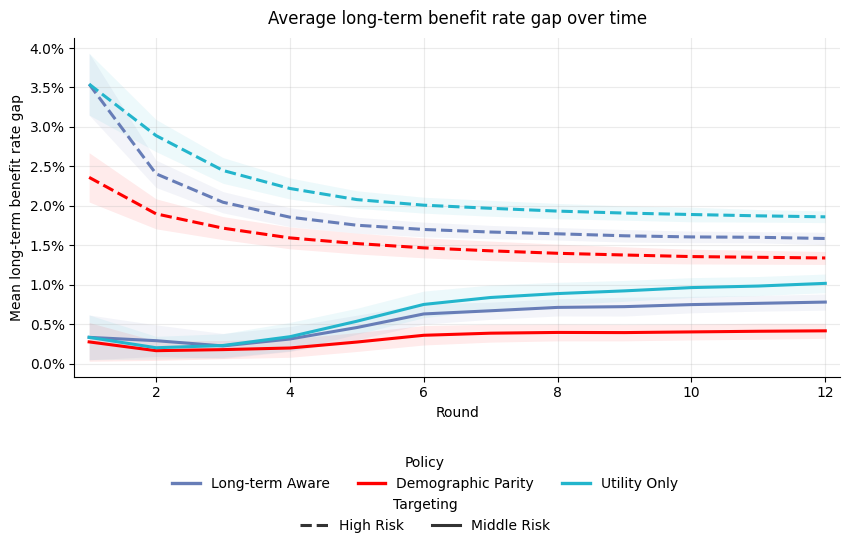

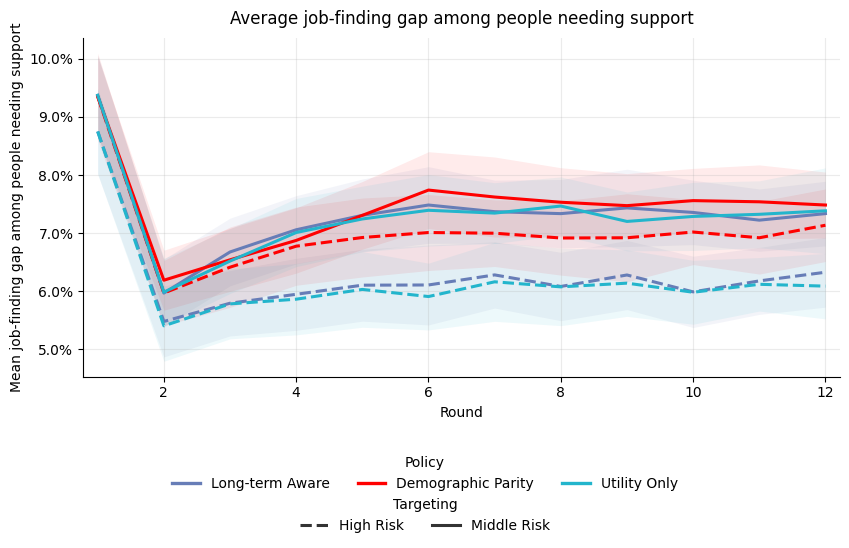

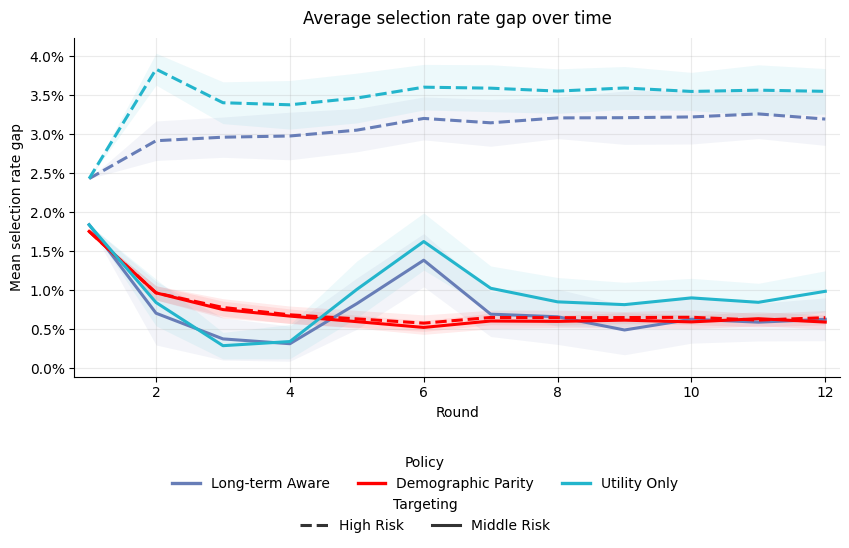

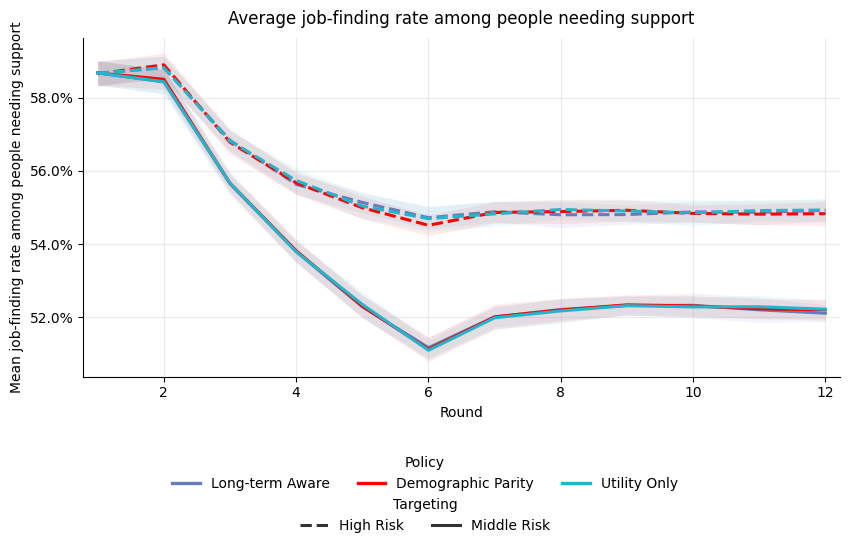

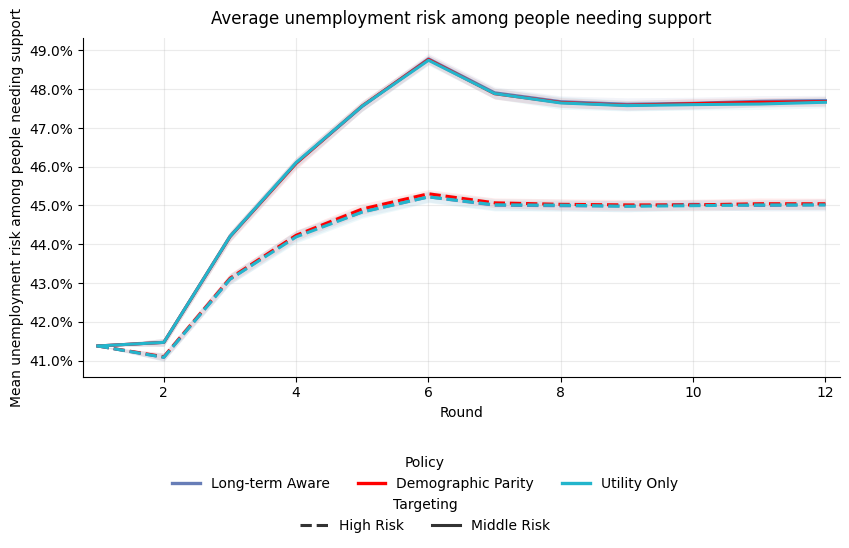

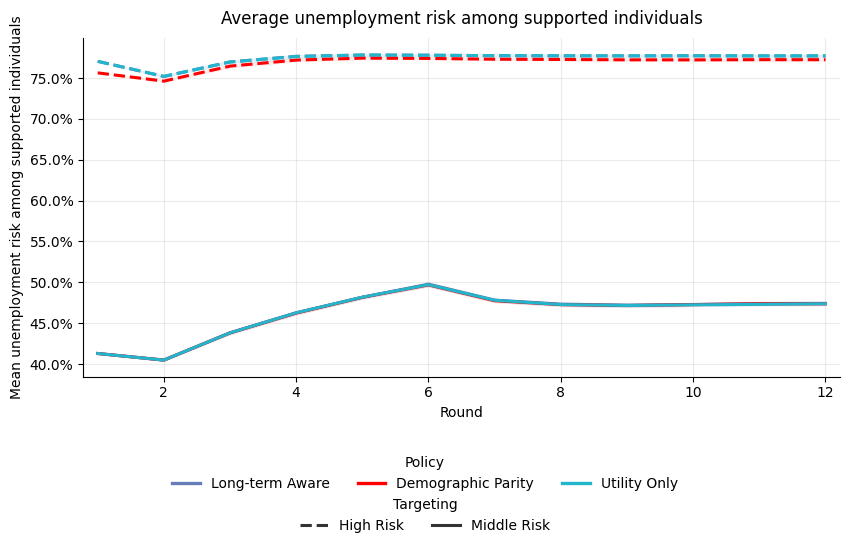

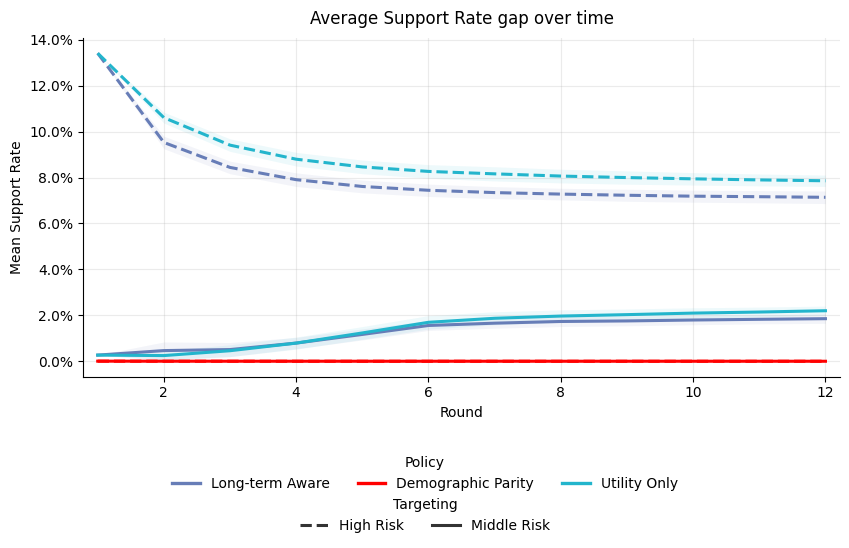

In [229]:
plot_metric_over_time(
    gap_over_time_avg,
    "benefit_rate_gap_mean",
    "benefit_rate_gap_sd",
    "Mean long-term benefit rate gap",
    "Average long-term benefit rate gap over time"
)

plot_metric_over_time(
    gap_over_time_avg,
    "job_finding_gap_mean",
    "job_finding_gap_sd",
    "Mean job-finding gap among people needing support",
    "Average job-finding gap among people needing support"
)

plot_metric_over_time(
    gap_over_time_avg,
    "selection_rate_gap_mean",
    "selection_rate_gap_sd",
    "Mean selection rate gap",
    "Average selection rate gap over time"
)

plot_metric_over_time(
    gap_over_time_avg,
    "job_finding_rate_among_need_mean",
    "job_finding_rate_among_need_sd",
    "Mean job-finding rate among people needing support",
    "Average job-finding rate among people needing support"
)

plot_metric_over_time(
    gap_over_time_avg,
    "avg_risk_among_need_mean",
    "avg_risk_among_need_sd",
    "Mean unemployment risk among people needing support",
    "Average unemployment risk among people needing support"
)

plot_metric_over_time(
    gap_over_time_avg,
    "avg_risk_supported_mean",
    "avg_risk_supported_sd",
    "Mean unemployment risk among supported individuals",
    "Average unemployment risk among supported individuals"
)

plot_metric_over_time(
    gap_over_time_avg,
    "support_rate_gap_mean",
    "support_rate_gap_sd",
    "Mean Support Rate",
    "Average Support Rate gap over time"
)



## Takeaways

1. **A score is only one part of the decision system.** The allocation rule determines who receives a scarce intervention.
2. **Targeting changes both fairness and utility.** High-risk targeting reaches a harder-need population and performs differently from middle-risk targeting.
3. **Static parity does not fully describe cumulative outcomes.** Long-term evaluation should track realized benefit relative to accumulated need.
4. **Interpret the experiment as a controlled illustration.** The ACS task supplies real demographic and employment structure, but the intervention effects and transition dynamics are simulated.
